/tmp/ipykernel_1611/1404210605.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[startCol] = pd.to_datetime(df[startCol], errors="coerce")


CONSTRUCTION CAREER NETWORK ANALYSIS — RQ1

Network structure
Nodes (roles): 30
Edges (transition types): 538
Total transitions: 3773
Density: 0.618
Reciprocity: 0.814
Largest weakly connected component: 30/30 (100.0%)

Path structure
Average effective separation: 1.27
Effective diameter: 2.00

Clustering
Global clustering: 0.804
Weighted average clustering: 0.029

Transition concentration
Gini coefficient: 0.651
Top 10% of transitions account for 54.1% of all moves

Top destination roles
10_ProjectEngineer: 541 incoming transitions
12_ProjectManager: 493 incoming transitions
9_OtherIntern: 317 incoming transitions
11_AssistantProjectManager: 304 incoming transitions
28_Others: 188 incoming transitions

Top source roles
9_OtherIntern: 536 outgoing transitions
10_ProjectEngineer: 498 outgoing transitions
12_ProjectManager: 301 outgoing transitions
28_Others: 270 outgoing transitions
11_AssistantProjectManager: 249 outgoing transitions

Top gateway roles (betweenness)
12_ProjectManager: 

/tmp/ipykernel_1611/1404210605.py:261: UserWarning: 

The arrowstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


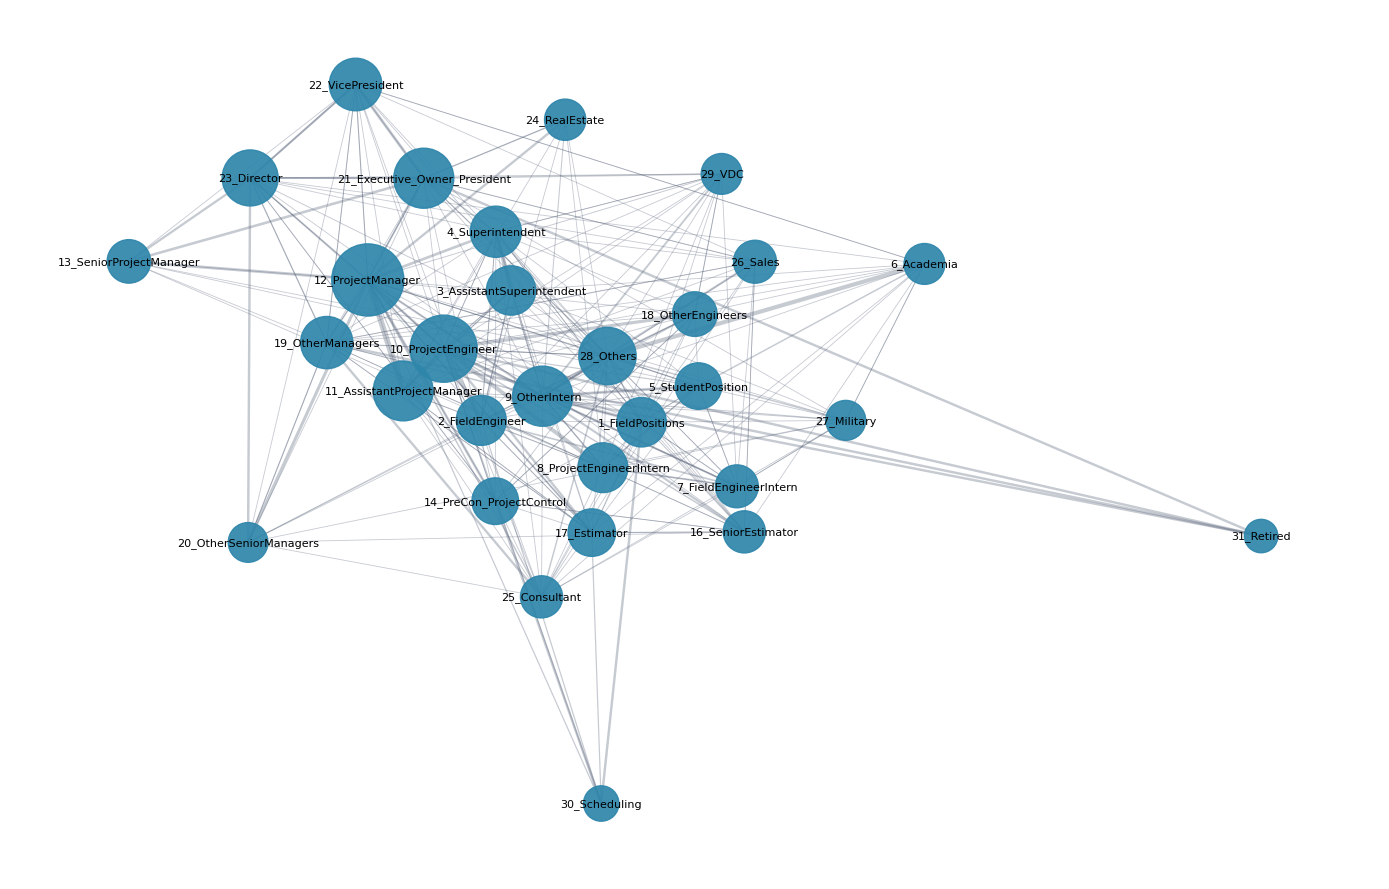

In [2]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# file path and key column names
path = "Final_job_timeline_with_detailed_clusters.csv"
idCol = "id"
roleCol = "detailed_cluster_label"
startCol = "start_date"
rankCol = "role_rank"

# plotting options
topN = 42
minProb = 0.03
showArrows = False

nodeColor = "#2E86AB"
edgeColor = "#5C677D"


# load and sort the data
df = pd.read_csv(path)
df[startCol] = pd.to_datetime(df[startCol], errors="coerce")
df = df[df[roleCol].notna()].copy()

sortCols = [idCol, startCol]
if rankCol in df.columns:
    sortCols.append(rankCol)

df = df.sort_values(sortCols)


def buildCareerNetwork(data):
    transitionList = []

    for _, group in data.groupby(idCol):
        group = group.reset_index(drop=True)

        for i in range(len(group) - 1):
            sourceRole = group.loc[i, roleCol]
            targetRole = group.loc[i + 1, roleCol]

            if pd.isna(sourceRole) or pd.isna(targetRole) or sourceRole == targetRole:
                continue

            transitionList.append((sourceRole, targetRole))

    edgeCounts = defaultdict(int)
    for sourceRole, targetRole in transitionList:
        edgeCounts[(sourceRole, targetRole)] += 1

    graph = nx.DiGraph()
    for (sourceRole, targetRole), weight in edgeCounts.items():
        graph.add_edge(sourceRole, targetRole, weight=float(weight))

    # add transition probability and a simple distance measure
    for node in graph.nodes():
        totalOutWeight = sum(graph[node][nbr]["weight"] for nbr in graph.successors(node))

        for nbr in graph.successors(node):
            weight = graph[node][nbr]["weight"]
            graph[node][nbr]["p"] = weight / totalOutWeight if totalOutWeight > 0 else 0.0
            graph[node][nbr]["distance"] = 1.0 / max(weight, 1e-9)

    return graph


G = buildCareerNetwork(df)


def giniCoefficient(values):
    values = np.array(values, dtype=float)

    if len(values) == 0 or np.sum(values) == 0:
        return 0.0

    values = np.sort(values)
    n = len(values)
    index = np.arange(1, n + 1)

    return np.sum((2 * index - n - 1) * values) / (n * np.sum(values))


def largestWccSubgraph(graph):
    if graph.number_of_nodes() == 0:
        return graph.copy()

    largestComponent = max(nx.weakly_connected_components(graph), key=len)
    return graph.subgraph(largestComponent).copy()


def runRq1Dashboard(graph, topK=5):
    print("CONSTRUCTION CAREER NETWORK ANALYSIS — RQ1")
    print("=" * 50)

    nodeCount = graph.number_of_nodes()
    edgeCount = graph.number_of_edges()
    totalTransitions = sum(data["weight"] for _, _, data in graph.edges(data=True))

    density = nx.density(graph) if nodeCount > 1 else 0.0
    reciprocity = nx.reciprocity(graph) if edgeCount > 0 else 0.0

    componentSizes = [len(component) for component in nx.weakly_connected_components(graph)] if nodeCount else []
    largestWcc = max(componentSizes) if componentSizes else 0
    largestWccShare = largestWcc / nodeCount if nodeCount else 0.0

    print("\nNetwork structure")
    print(f"Nodes (roles): {nodeCount}")
    print(f"Edges (transition types): {edgeCount}")
    print(f"Total transitions: {int(totalTransitions)}")
    print(f"Density: {density:.3f}")
    print(f"Reciprocity: {reciprocity:.3f}")
    print(f"Largest weakly connected component: {largestWcc}/{nodeCount} ({largestWccShare * 100:.1f}%)")

    subgraph = largestWccSubgraph(graph)
    undirectedGraph = subgraph.to_undirected()

    avgPath = None
    diameter = None

    print("\nPath structure")
    if undirectedGraph.number_of_nodes() > 1 and nx.is_connected(undirectedGraph):
        avgPath = nx.average_shortest_path_length(undirectedGraph)
        diameter = nx.diameter(undirectedGraph)
        print(f"Average effective separation: {avgPath:.2f}")
        print(f"Effective diameter: {diameter:.2f}")
    else:
        print("Not enough connectivity to compute path measures.")

    clusteringGlobal = None
    clusteringAvg = None

    print("\nClustering")
    if undirectedGraph.number_of_nodes() >= 3:
        clusteringGlobal = nx.transitivity(undirectedGraph)
        clusteringAvg = nx.average_clustering(undirectedGraph, weight="weight")
        print(f"Global clustering: {clusteringGlobal:.3f}")
        print(f"Weighted average clustering: {clusteringAvg:.3f}")
    else:
        print("Clustering could not be computed.")

    edgeWeights = np.array([data["weight"] for _, _, data in graph.edges(data=True)], dtype=float)
    gini = giniCoefficient(edgeWeights)

    topCount = max(1, len(edgeWeights) // 10) if len(edgeWeights) else 0
    topShare = (
        np.sum(np.sort(edgeWeights)[-topCount:]) / np.sum(edgeWeights) * 100
        if topCount and np.sum(edgeWeights)
        else 0.0
    )

    print("\nTransition concentration")
    print(f"Gini coefficient: {gini:.3f}")
    print(f"Top 10% of transitions account for {topShare:.1f}% of all moves")

    inStrength = dict(graph.in_degree(weight="weight"))
    outStrength = dict(graph.out_degree(weight="weight"))
    pagerank = nx.pagerank(graph, alpha=0.85, weight="weight")
    betweenness = nx.betweenness_centrality(graph, weight="distance", normalized=True)

    topIn = sorted(inStrength.items(), key=lambda x: x[1], reverse=True)[:topK]
    topOut = sorted(outStrength.items(), key=lambda x: x[1], reverse=True)[:topK]
    topPr = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:topK]
    topBet = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:topK]

    print("\nTop destination roles")
    for role, count in topIn:
        print(f"{role}: {int(count)} incoming transitions")

    print("\nTop source roles")
    for role, count in topOut:
        print(f"{role}: {int(count)} outgoing transitions")

    print("\nTop gateway roles (betweenness)")
    for role, score in topBet:
        print(f"{role}: {score:.3f}")

    print("\nTop roles by PageRank")
    for role, score in topPr:
        print(f"{role}: {score:.3f}")

    communities = None
    modularity = None

    print("\nCommunity structure")
    try:
        communities = nx.community.louvain_communities(undirectedGraph, weight="weight", seed=42)
        modularity = nx.community.modularity(undirectedGraph, communities, weight="weight")

        print(f"Number of communities: {len(communities)}")
        print(f"Modularity: {modularity:.3f}")

        for i, community in enumerate(sorted(communities, key=len, reverse=True), start=1):
            if len(community) >= 3:
                print(f"\nCommunity {i} ({len(community)} roles)")
                for role in sorted(community):
                    print(f"- {role}")
    except Exception:
        print("Community detection was not available in this environment.")

    return {
        "density": density,
        "reciprocity": reciprocity,
        "largest_wcc_share": largestWccShare,
        "avg_path_distance": avgPath,
        "diameter_distance": diameter,
        "clustering_global": clusteringGlobal,
        "clustering_avg": clusteringAvg,
        "transition_gini": gini,
        "top10_share": topShare,
        "in_strength": inStrength,
        "out_strength": outStrength,
        "pagerank": pagerank,
        "betweenness": betweenness,
        "communities": communities,
        "modularity": modularity,
    }


dash = runRq1Dashboard(G, topK=5)


def topSubgraphByPagerank(graph, k, minP):
    if graph.number_of_edges() == 0:
        return graph.copy(), {node: 0.0 for node in graph.nodes()}

    pagerankScores = nx.pagerank(graph, alpha=0.85, weight="weight")
    topNodes = set(sorted(graph.nodes(), key=lambda node: pagerankScores.get(node, 0.0), reverse=True)[:k])

    subgraph = graph.subgraph(topNodes).copy()
    edgesToRemove = [
        (u, v)
        for u, v, data in subgraph.edges(data=True)
        if data.get("p", 0.0) < minP
    ]
    subgraph.remove_edges_from(edgesToRemove)

    return subgraph, pagerankScores


def drawPreferredNetwork(graph, pagerankScores, title, seed=11):
    if graph.number_of_nodes() == 0:
        plt.gca().set_axis_off()
        plt.title(title)
        return

    pos = nx.spring_layout(
        graph,
        k=0.8 / np.sqrt(max(1, graph.number_of_nodes())),
        iterations=250,
        seed=seed
    )

    nodeSizes = np.array([pagerankScores.get(node, 0.0) for node in graph.nodes()], dtype=float)
    nodeSizes = 2600 * ((nodeSizes / (nodeSizes.max() if nodeSizes.max() > 0 else 1)) ** 0.55) + 100

    edgeWidths = [max(0.6, 7.0 * data.get("p", 0.0)) for _, _, data in graph.edges(data=True)]

    nx.draw_networkx_edges(
        graph,
        pos,
        edge_color=edgeColor,
        width=edgeWidths,
        alpha=0.35,
        arrows=showArrows,
        arrowstyle="->",
        arrowsize=10
    )
    nx.draw_networkx_nodes(graph, pos, node_color=nodeColor, node_size=nodeSizes, alpha=0.92)
    nx.draw_networkx_labels(graph, pos, font_size=8)

    plt.title(title)
    plt.axis("off")


H_plot, pr_all = topSubgraphByPagerank(G, topN, minProb)

plt.figure(figsize=(14, 9))
drawPreferredNetwork(H_plot, pr_all, "")
plt.tight_layout()
plt.show()

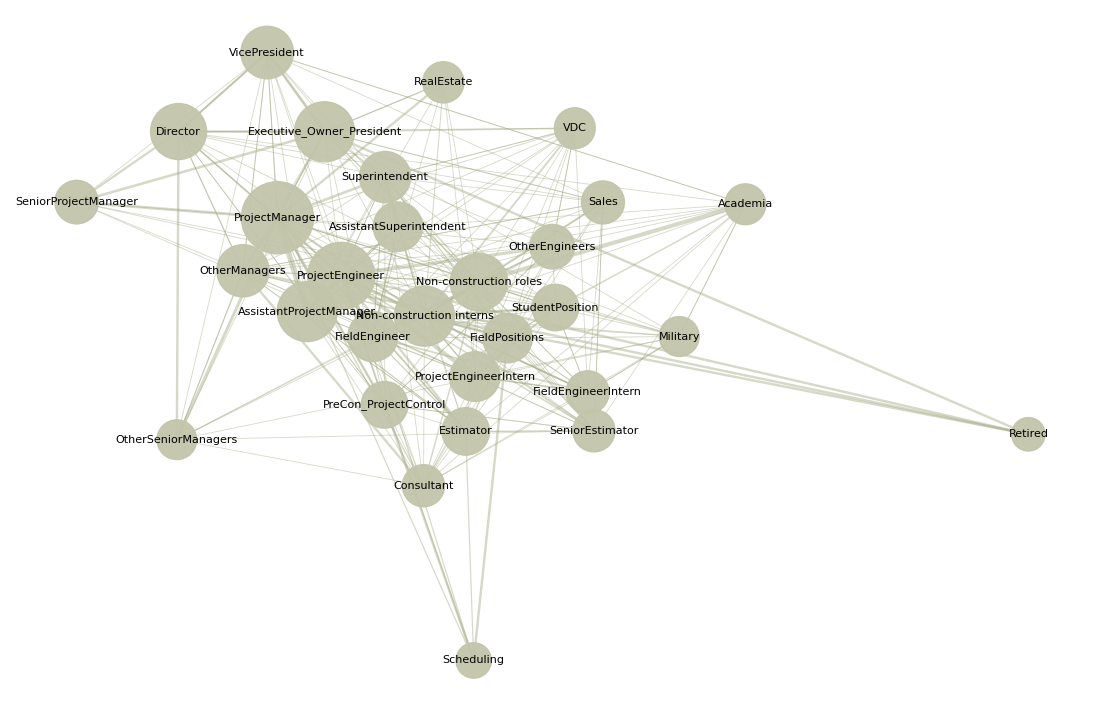

In [3]:
import re
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

def stripPrefix(name):
    """
    Removes:
      - leading digits + underscore  (e.g., 22_)
      - leading underscore           (e.g., _Role)
    Keeps everything else unchanged.
    """
    s = str(name)
    s = re.sub(r'^\d+_', '', s)  # remove leading digits + underscore
    s = re.sub(r'^_', '', s)     # remove leading underscore if still present
    return s

def renameForFigure(name):
    """
    ONLY renames specific clusters for clearer figures.
    Does NOT change anything else.
    """
    s = stripPrefix(name)
    sLower = s.strip().lower()

    # Normalize intern variants by removing spaces/underscores
    compact = re.sub(r'[\s_]+', '', sLower)

    if sLower == "others":
        return "Non-construction roles"

    # catch: "Other interns", "OtherIntern", "Other_Interns", etc.
    if compact in {"otherintern", "otherinterns", "othersintern", "othersinterns"}:
        return "Non-construction interns"

    return s

def redraw_same_plot_clean_labels(G, pr, seed=11, figsize=(14, 9),
                                  node_color="#c2c5aa",
                                  edge_color="#a4ac86"):

    fig, ax = plt.subplots(figsize=figsize)

    # --- EXACT same layout as original ---
    pos = nx.spring_layout(
        G,
        k=0.8 / np.sqrt(max(1, G.number_of_nodes())),
        iterations=250,
        seed=seed
    )

    # --- SAME node sizing ---
    s = np.array([pr.get(n, 0.0) for n in G.nodes()], float)
    s = 2600 * ((s / (s.max() if s.max() > 0 else 1)) ** 0.55) + 100

    # --- SAME edge widths ---
    w = [max(0.6, 7.0 * d.get("p", 0.0)) for *_, d in G.edges(data=True)]

    # --- draw (unchanged except colors) ---
    nx.draw_networkx_edges(G, pos, width=w, alpha=0.45,
                           arrows=False, edge_color=edge_color, ax=ax)

    nx.draw_networkx_nodes(G, pos, node_size=s, alpha=0.95,
                           node_color=node_color, ax=ax)

    labels = {n: renameForFigure(n) for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, ax=ax)

    ax.set_axis_off()
    ax.margins(0)

    # tight crop (UNCHANGED: 0.06 padding)
    xs = np.array([pos[n][0] for n in G.nodes()])
    ys = np.array([pos[n][1] for n in G.nodes()])
    xpad = 0.07 * (xs.max() - xs.min() + 1e-9)
    ypad = 0.07 * (ys.max() - ys.min() + 1e-9)

    ax.set_xlim(xs.min() - xpad, xs.max() + xpad)
    ax.set_ylim(ys.min() - ypad, ys.max() + ypad)

    return fig

# --- redraw using your existing graph ---
fig = redraw_same_plot_clean_labels(H_plot, pr_all)

# --- save final publication version ---
fig.savefig("RQ1_network_FINAL.png", dpi=400, bbox_inches="tight", pad_inches=0.02)
fig.savefig("RQ1_network_FINAL.pdf", bbox_inches="tight", pad_inches=0.02)

plt.show()


/tmp/ipykernel_1611/342307652.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[START] = pd.to_datetime(df[START], errors="coerce")


RQ2B: GENDER NETWORK COMPARISON
gender  n_people  nodes  edges  total_transitions  density  reciprocity     gini  top10_share_pct  n_communities  modularity
female       167     29    221              585.0 0.272167     0.561086 0.506478        46.324786              3    0.247139
  male      1014     30    513             3188.0 0.589655     0.799220 0.634175        52.917189              3    0.245877


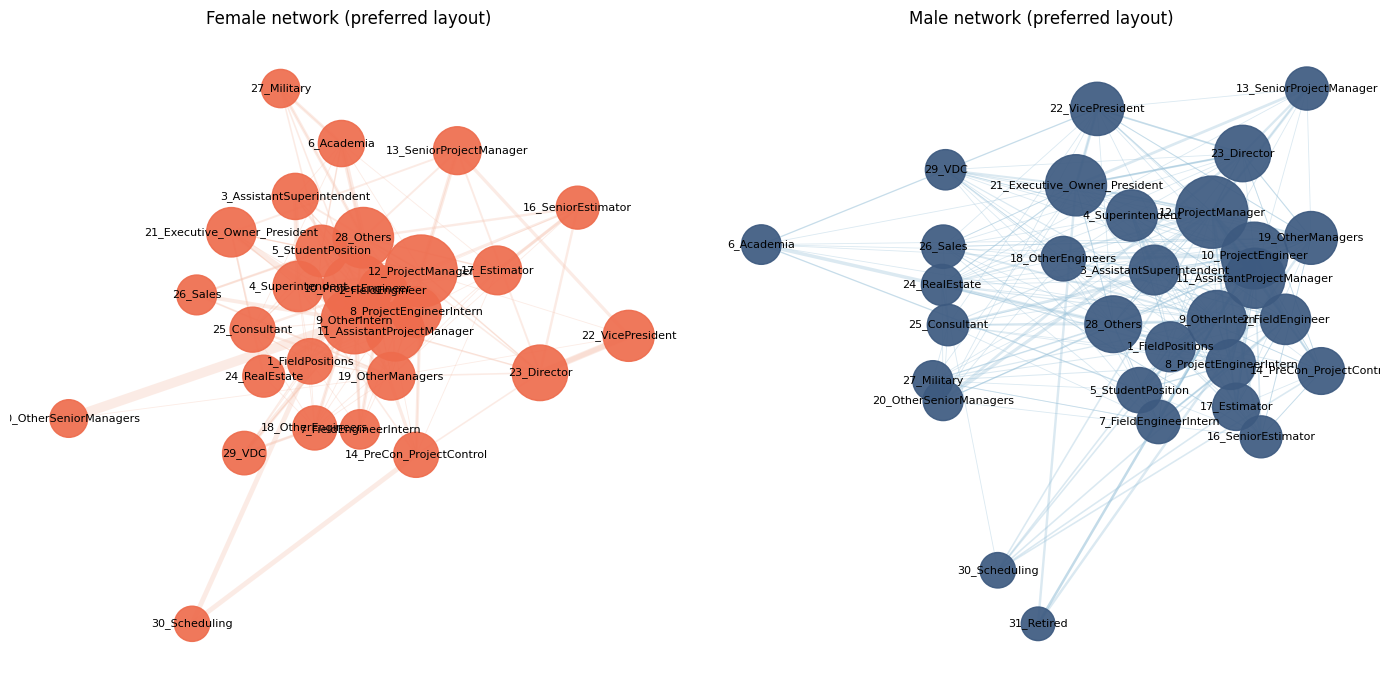

In [4]:
# Gender networks (male vs female)
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

PATH = "Final_job_timeline_with_detailed_clusters.csv"
ID, ROLE, START, RANK = "id", "detailed_cluster_label", "start_date", "role_rank"
GENDER = "gender"

# --- plot style (your earlier palette)
TOPN = 42
MIN_P = 0.03
ARROW = False
F_NODE, F_EDGE = "#EE6C4D", "#F6C8B6"
M_NODE, M_EDGE = "#3D5A80", "#98C1D9"

df = pd.read_csv(PATH)
df[START] = pd.to_datetime(df[START], errors="coerce")
df = df[~df[ROLE].isna()].copy()
df[GENDER] = df.get(GENDER, "").astype(str).str.strip().str.lower()

sortCols = [ID, START]
if RANK in df.columns:
    sortCols.append(RANK)
df = df.sort_values(sortCols)

def buildCareerNetwork(data):
    transitions = []
    for pid, g in data.groupby(ID):
        g = g.reset_index(drop=True)
        for i in range(len(g) - 1):
            s, d = g.loc[i, ROLE], g.loc[i + 1, ROLE]
            if pd.isna(s) or pd.isna(d) or s == d:
                continue
            transitions.append((s, d))

    edgeCounts = defaultdict(int)
    for s, d in transitions:
        edgeCounts[(s, d)] += 1

    G = nx.DiGraph()
    for (s, d), w in edgeCounts.items():
        G.add_edge(s, d, weight=float(w))

    for u in G.nodes():
        outW = sum(G[u][v]["weight"] for v in G.successors(u))
        for v in G.successors(u):
            w = G[u][v]["weight"]
            G[u][v]["p"] = (w / outW) if outW > 0 else 0.0
            G[u][v]["distance"] = 1.0 / max(w, 1e-9)
    return G

def giniCoefficient(x):
    x = np.array(list(x), dtype=float)
    if len(x) == 0 or np.sum(x) == 0:
        return 0.0
    x = np.sort(x)
    n = len(x)
    idx = np.arange(1, n + 1)
    return (np.sum((2 * idx - n - 1) * x)) / (n * np.sum(x))

def computeMetrics(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    totalT = float(sum(d["weight"] for _, _, d in G.edges(data=True))) if m else 0.0
    density = nx.density(G) if n > 1 else 0.0
    reciprocity = nx.reciprocity(G) if m > 0 else 0.0

    weights = np.array([d["weight"] for _, _, d in G.edges(data=True)], dtype=float)
    gini = giniCoefficient(weights)
    topCount = max(1, len(weights)//10) if len(weights) else 0
    top10 = (np.sum(np.sort(weights)[-topCount:]) / np.sum(weights) * 100) if topCount and np.sum(weights) else 0.0

    modularity, nComms = np.nan, np.nan
    try:
        H = G.to_undirected()
        comms = nx.community.louvain_communities(H, weight="weight", seed=42)
        modularity = nx.community.modularity(H, comms, weight="weight")
        nComms = len(comms)
    except Exception:
        pass

    return dict(nodes=n, edges=m, total_transitions=totalT, density=density, reciprocity=reciprocity,
                gini=gini, top10_share_pct=top10, n_communities=nComms, modularity=modularity)

def topSubgraphByPagerank(G, k, minP):
    if G.number_of_edges() == 0:
        return G.copy(), {n: 0.0 for n in G.nodes()}
    pr = nx.pagerank(G, alpha=0.85, weight="weight")
    keep = set(sorted(G.nodes(), key=lambda n: pr.get(n, 0.0), reverse=True)[:k])
    H = G.subgraph(keep).copy()
    H.remove_edges_from([(u, v) for u, v, d in H.edges(data=True) if d.get("p", 0.0) < minP])
    return H, pr

def drawPreferred(G, pr, nodeColor, edgeColor, seed, title):
    if G.number_of_nodes() == 0:
        plt.gca().set_axis_off()
        plt.title(title)
        return
    pos = nx.spring_layout(G, k=0.8/np.sqrt(max(1, G.number_of_nodes())), iterations=250, seed=seed)
    s = np.array([pr.get(n, 0.0) for n in G.nodes()], float)
    s = 2600 * ((s / (s.max() if s.max() > 0 else 1)) ** 0.55) + 100
    w = [max(0.6, 7.0 * d.get("p", 0.0)) for *_, d in G.edges(data=True)]
    nx.draw_networkx_edges(G, pos, edge_color=edgeColor, width=w, alpha=0.35, arrows=ARROW)
    nx.draw_networkx_nodes(G, pos, node_color=nodeColor, node_size=s, alpha=0.92)
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.title(title)
    plt.axis("off")

df2 = df[df[GENDER].isin(["male", "female"])].copy()

Gf = buildCareerNetwork(df2[df2[GENDER] == "female"])
Gm = buildCareerNetwork(df2[df2[GENDER] == "male"])

mf = computeMetrics(Gf)
mm = computeMetrics(Gm)

print("RQ2B: GENDER NETWORK COMPARISON")
print("="*30)
out = pd.DataFrame([
    {"gender":"female", "n_people": df2[df2[GENDER]=="female"][ID].nunique(), **mf},
    {"gender":"male", "n_people": df2[df2[GENDER]=="male"][ID].nunique(), **mm},
])
print(out[["gender","n_people","nodes","edges","total_transivitions" if "total_transivitions" in out.columns else "total_transitions",
           "density","reciprocity","gini","top10_share_pct","n_communities","modularity"]].to_string(index=False))

Hf, prf = topSubgraphByPagerank(Gf, TOPN, MIN_P)
Hm, prm = topSubgraphByPagerank(Gm, TOPN, MIN_P)

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
drawPreferred(Hf, prf, F_NODE, F_EDGE, seed=11, title="Female network (preferred layout)")
plt.subplot(1, 2, 2)
drawPreferred(Hm, prm, M_NODE, M_EDGE, seed=13, title="Male network (preferred layout)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_1611/1855907963.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[START] = pd.to_datetime(df[START], errors="coerce")


RQ2B: GENDER NETWORK COMPARISON
gender  n_people  nodes  edges  total_transitions  density  reciprocity     gini  top10_share_pct  n_communities  modularity
female       167     29    221              585.0 0.272167     0.561086 0.506478        46.324786              3    0.247139
  male      1014     30    513             3188.0 0.589655     0.799220 0.634175        52.917189              3    0.245877


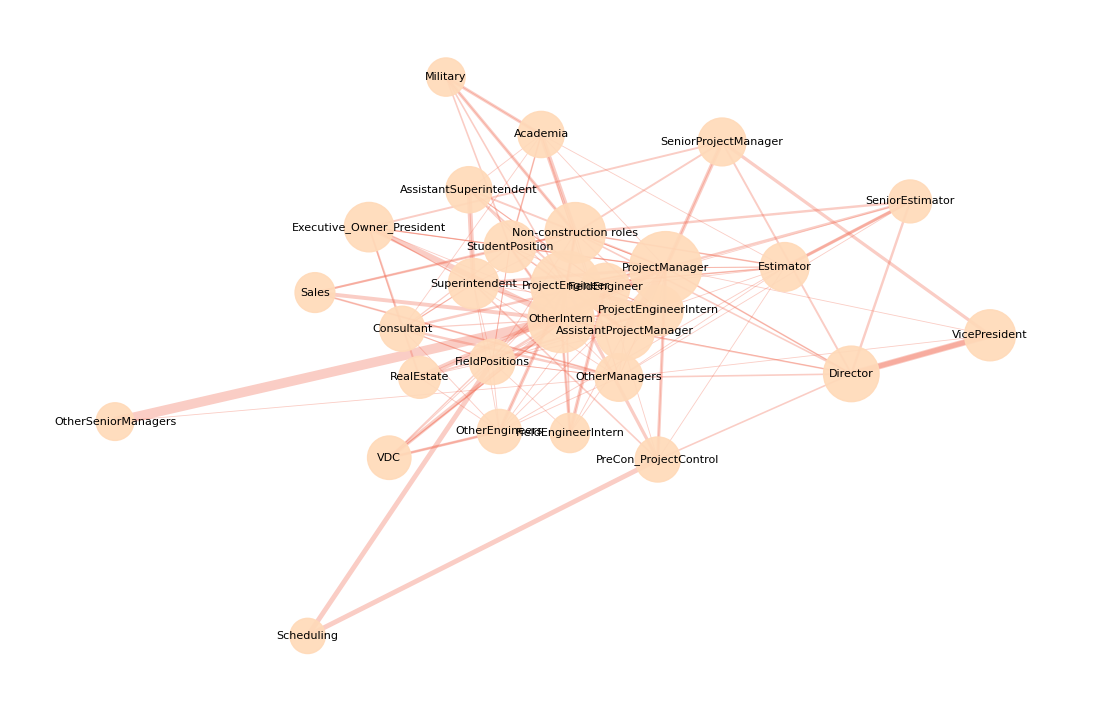

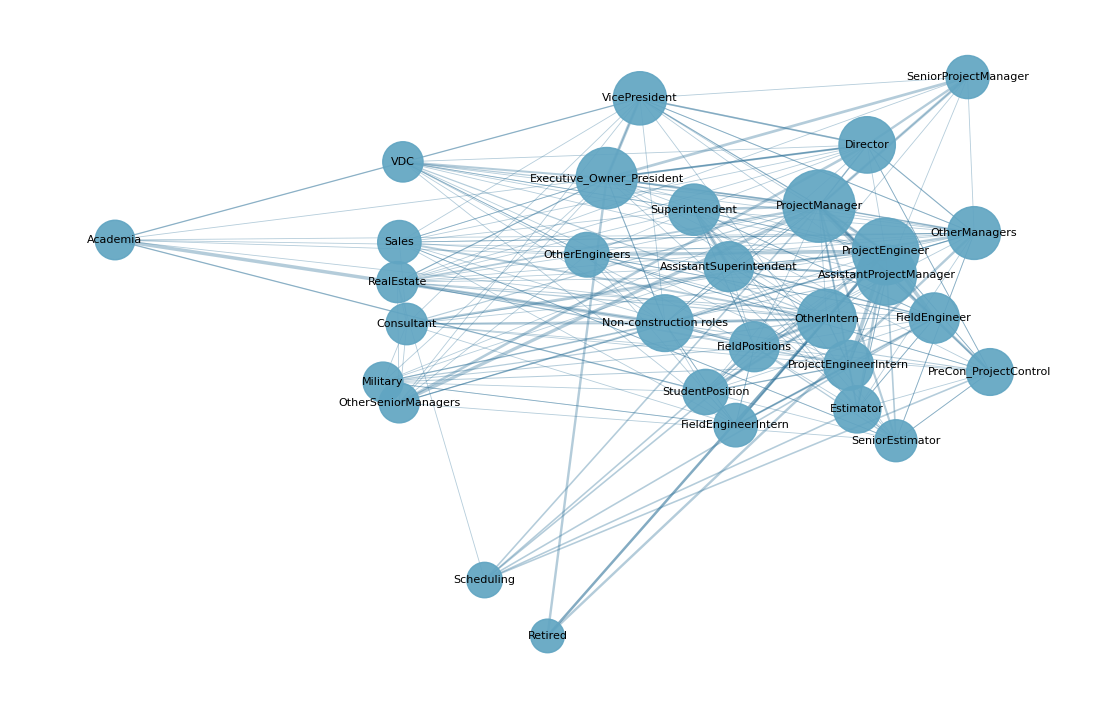

In [5]:
#Gender networks clean labels
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import re

PATH = "Final_job_timeline_with_detailed_clusters.csv"
ID, ROLE, START, RANK = "id", "detailed_cluster_label", "start_date", "role_rank"
GENDER = "gender"

# style
TOPN = 42
MIN_P = 0.03
ARROW = False
F_NODE, F_EDGE = "#ffdab9", "#f27059"
M_NODE, M_EDGE = "#61a5c2", "#2a6f97"

# -----------------------------
# label cleaning (ONLY prefix cleanup)
# -----------------------------
def stripPrefix(name):
    s = str(name)
    s = re.sub(r"^\d+_", "", s)  # remove leading digits + underscore
    s = re.sub(r"^_", "", s)     # remove leading underscore
    return s

# -----------------------------
# rename specific cluster labels (ONLY for figures)
# -----------------------------
def renameForFigure(name):
    s = stripPrefix(name)
    sLower = s.strip().lower()

    if sLower == "others":
        return "Non-construction roles"

    if sLower in {"other interns", "otherinterns", "others interns", "othersinterns"}:
        return "Non-construction interns"

    return s

# -----------------------------
# load + prep
# -----------------------------
df = pd.read_csv(PATH)
df[START] = pd.to_datetime(df[START], errors="coerce")
df = df[~df[ROLE].isna()].copy()
df[GENDER] = df.get(GENDER, "").astype(str).str.strip().str.lower()

sortCols = [ID, START]
if RANK in df.columns:
    sortCols.append(RANK)
df = df.sort_values(sortCols)

# -----------------------------
# build network
# -----------------------------
def buildCareerNetwork(data):
    transitions = []
    for pid, g in data.groupby(ID):
        g = g.reset_index(drop=True)
        for i in range(len(g) - 1):
            s, d = g.loc[i, ROLE], g.loc[i + 1, ROLE]
            if pd.isna(s) or pd.isna(d) or s == d:
                continue
            transitions.append((s, d))

    edgeCounts = defaultdict(int)
    for s, d in transitions:
        edgeCounts[(s, d)] += 1

    G = nx.DiGraph()
    for (s, d), w in edgeCounts.items():
        G.add_edge(s, d, weight=float(w))

    for u in G.nodes():
        outW = sum(G[u][v]["weight"] for v in G.successors(u))
        for v in G.successors(u):
            w = G[u][v]["weight"]
            G[u][v]["p"] = (w / outW) if outW > 0 else 0.0
            G[u][v]["distance"] = 1.0 / max(w, 1e-9)
    return G

# -----------------------------
# metrics
# -----------------------------
def giniCoefficient(x):
    x = np.array(list(x), dtype=float)
    if len(x) == 0 or np.sum(x) == 0:
        return 0.0
    x = np.sort(x)
    n = len(x)
    idx = np.arange(1, n + 1)
    return (np.sum((2 * idx - n - 1) * x)) / (n * np.sum(x))

def computeMetrics(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    totalT = float(sum(d["weight"] for _, _, d in G.edges(data=True))) if m else 0.0
    density = nx.density(G) if n > 1 else 0.0
    reciprocity = nx.reciprocity(G) if m > 0 else 0.0

    weights = np.array([d["weight"] for _, _, d in G.edges(data=True)], dtype=float)
    gini = giniCoefficient(weights)
    topCount = max(1, len(weights)//10) if len(weights) else 0
    top10 = (np.sum(np.sort(weights)[-topCount:]) / np.sum(weights) * 100) if topCount and np.sum(weights) else 0.0

    modularity, nComms = np.nan, np.nan
    try:
        H = G.to_undirected()
        comms = nx.community.louvain_communities(H, weight="weight", seed=42)
        modularity = nx.community.modularity(H, comms, weight="weight")
        nComms = len(comms)
    except Exception:
        pass

    return dict(nodes=n, edges=m, total_transitions=totalT, density=density, reciprocity=reciprocity,
                gini=gini, top10_share_pct=top10, n_communities=nComms, modularity=modularity)

# -----------------------------
# top PageRank subgraph
# -----------------------------
def topSubgraphByPagerank(G, k, minP):
    if G.number_of_edges() == 0:
        return G.copy(), {n: 0.0 for n in G.nodes()}
    pr = nx.pagerank(G, alpha=0.85, weight="weight")
    keep = set(sorted(G.nodes(), key=lambda n: pr.get(n, 0.0), reverse=True)[:k])
    H = G.subgraph(keep).copy()
    H.remove_edges_from([(u, v) for u, v, d in H.edges(data=True) if d.get("p", 0.0) < minP])
    return H, pr

# -----------------------------
# draw (preferred style + clean labels)
# -----------------------------
def drawPreferredClean(G, pr, nodeColor, edgeColor, seed, title, outPrefix):
    fig, ax = plt.subplots(figsize=(14, 9))

    if G.number_of_nodes() == 0:
        ax.set_axis_off()
        ax.set_title(title)
        fig.savefig(f"{outPrefix}.png", dpi=400, bbox_inches="tight", pad_inches=0.02)
        fig.savefig(f"{outPrefix}.pdf", bbox_inches="tight", pad_inches=0.02)
        plt.show()
        return

    pos = nx.spring_layout(G, k=0.8/np.sqrt(max(1, G.number_of_nodes())), iterations=250, seed=seed)

    s = np.array([pr.get(n, 0.0) for n in G.nodes()], float)
    s = 2600 * ((s / (s.max() if s.max() > 0 else 1)) ** 0.55) + 100

    w = [max(0.6, 7.0 * d.get("p", 0.0)) for *_, d in G.edges(data=True)]

    nx.draw_networkx_edges(G, pos, edge_color=edgeColor, width=w, alpha=0.35, arrows=ARROW, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_color=nodeColor, node_size=s, alpha=0.92, ax=ax)

    labels = {n: renameForFigure(n) for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, ax=ax)

    ax.set_title(title)
    ax.axis("off")
    ax.margins(0)

    xs = np.array([pos[n][0] for n in G.nodes()])
    ys = np.array([pos[n][1] for n in G.nodes()])

    xspan = xs.max() - xs.min() + 1e-9
    yspan = ys.max() - ys.min() + 1e-9

    xpad = 0.12 * xspan
    ypad = 0.12 * yspan

    ax.set_xlim(xs.min() - xpad, xs.max() + xpad)
    ax.set_ylim(ys.min() - ypad, ys.max() + ypad)


    fig.savefig(f"{outPrefix}.png", dpi=400, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(f"{outPrefix}.pdf", bbox_inches="tight", pad_inches=0.02)
    plt.show()

# -----------------------------
# run
# -----------------------------
df2 = df[df[GENDER].isin(["male", "female"])].copy()

Gf = buildCareerNetwork(df2[df2[GENDER] == "female"])
Gm = buildCareerNetwork(df2[df2[GENDER] == "male"])

mf = computeMetrics(Gf)
mm = computeMetrics(Gm)

print("RQ2B: GENDER NETWORK COMPARISON")
print("="*30)
out = pd.DataFrame([
    {"gender":"female", "n_people": df2[df2[GENDER]=="female"][ID].nunique(), **mf},
    {"gender":"male", "n_people": df2[df2[GENDER]=="male"][ID].nunique(), **mm},
])
print(out[["gender","n_people","nodes","edges","total_transitions",
           "density","reciprocity","gini","top10_share_pct","n_communities","modularity"]].to_string(index=False))

Hf, prf = topSubgraphByPagerank(Gf, TOPN, MIN_P)
Hm, prm = topSubgraphByPagerank(Gm, TOPN, MIN_P)

drawPreferredClean(Hf, prf, F_NODE, F_EDGE, seed=11,
                   title="",
                   outPrefix="RQ2B_female_network")

drawPreferredClean(Hm, prm, M_NODE, M_EDGE, seed=13,
                   title="",
                   outPrefix="RQ2B_male_network")


/tmp/ipykernel_1611/2243822793.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[START] = pd.to_datetime(df[START], errors="coerce")


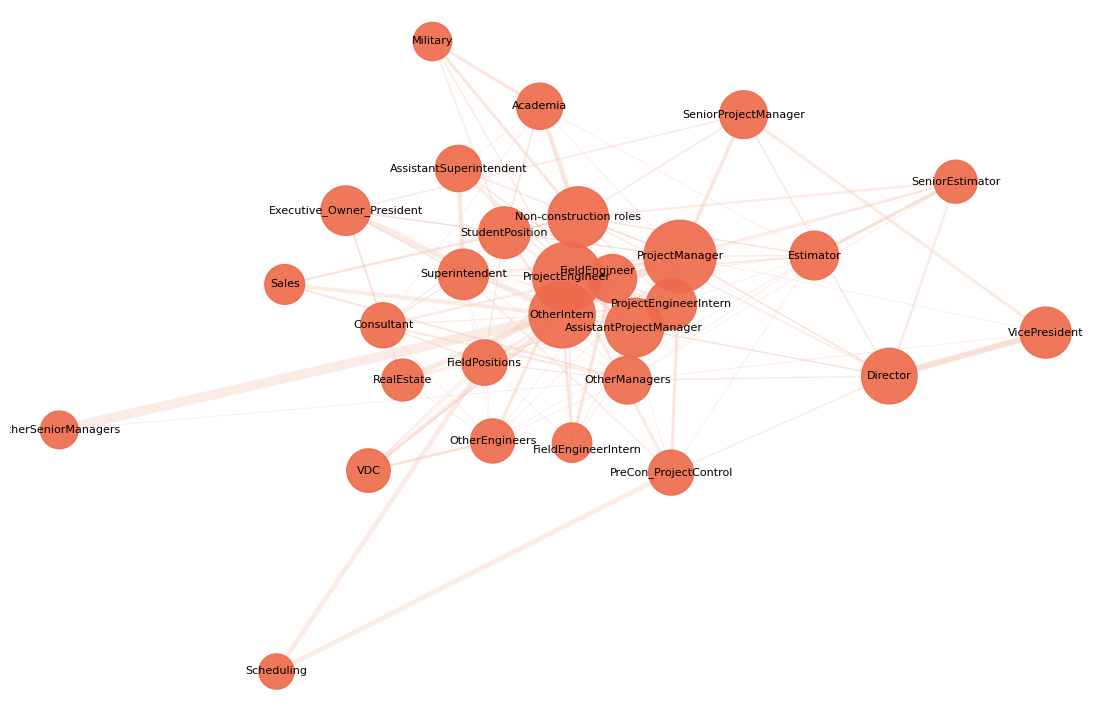

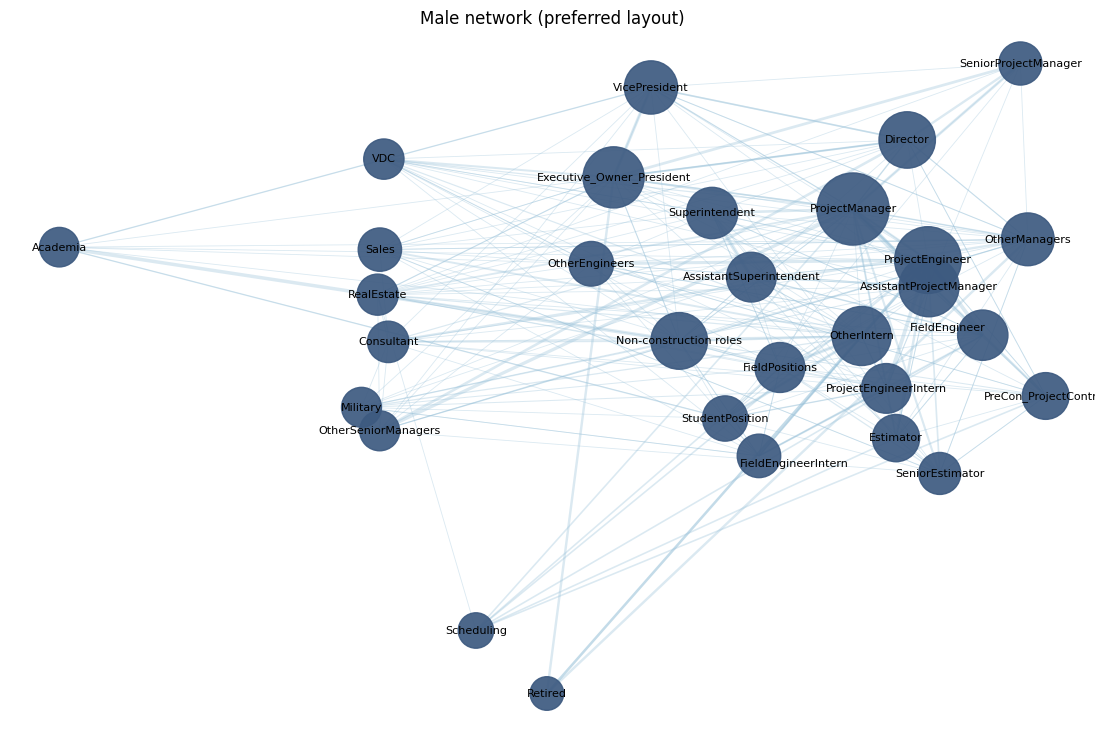

In [6]:
#Gender networks
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import re

PATH = "Final_job_timeline_with_detailed_clusters.csv"
ID, ROLE, START, RANK = "id", "detailed_cluster_label", "start_date", "role_rank"
GENDER = "gender"

TOPN = 42
MIN_P = 0.03
ARROW = False
F_NODE, F_EDGE = "#EE6C4D", "#F6C8B6"
M_NODE, M_EDGE = "#3D5A80", "#98C1D9"

# -----------------------------
# label cleaning (prefix only)
# -----------------------------
def stripPrefix(name):
    s = str(name)
    s = re.sub(r"^\d+_", "", s)  # remove leading digits + underscore
    s = re.sub(r"^_", "", s)     # remove leading underscore
    return s

# -----------------------------
# rename specific cluster labels (for figures)
# -----------------------------
def renameForFigure(name):
    s = stripPrefix(name)
    sLower = s.strip().lower()

    if sLower == "others":
        return "Non-construction roles"

    # handle a few possible spellings
    if sLower in {"other interns", "otherinterns", "others interns", "othersinterns"}:
        return "Non-construction interns"

    return s

# -----------------------------
# load + prep
# -----------------------------
df = pd.read_csv(PATH)
df[START] = pd.to_datetime(df[START], errors="coerce")
df = df[~df[ROLE].isna()].copy()
df[GENDER] = df.get(GENDER, "").astype(str).str.strip().str.lower()

sortCols = [ID, START]
if RANK in df.columns:
    sortCols.append(RANK)
df = df.sort_values(sortCols)

# -----------------------------
# build network
# -----------------------------
def buildCareerNetwork(data):
    transitions = []
    for pid, g in data.groupby(ID):
        g = g.reset_index(drop=True)
        for i in range(len(g) - 1):
            s, d = g.loc[i, ROLE], g.loc[i + 1, ROLE]
            if pd.isna(s) or pd.isna(d) or s == d:
                continue
            transitions.append((s, d))

    edgeCounts = defaultdict(int)
    for s, d in transitions:
        edgeCounts[(s, d)] += 1

    G = nx.DiGraph()
    for (s, d), w in edgeCounts.items():
        G.add_edge(s, d, weight=float(w))

    for u in G.nodes():
        outW = sum(G[u][v]["weight"] for v in G.successors(u))
        for v in G.successors(u):
            w = G[u][v]["weight"]
            G[u][v]["p"] = (w / outW) if outW > 0 else 0.0
            G[u][v]["distance"] = 1.0 / max(w, 1e-9)
    return G

def topSubgraphByPagerank(G, k, minP):
    if G.number_of_edges() == 0:
        return G.copy(), {n: 0.0 for n in G.nodes()}
    pr = nx.pagerank(G, alpha=0.85, weight="weight")
    keep = set(sorted(G.nodes(), key=lambda n: pr.get(n, 0.0), reverse=True)[:k])
    H = G.subgraph(keep).copy()
    H.remove_edges_from([(u, v) for u, v, d in H.edges(data=True) if d.get("p", 0.0) < minP])
    return H, pr

# -----------------------------
# draw function (manual 2-label offset ONLY)
# -----------------------------
def drawPreferred_manualFix(G, pr, nodeColor, edgeColor, seed, title, outPrefix):
    fig, ax = plt.subplots(figsize=(14, 9))

    if G.number_of_nodes() == 0:
        ax.set_axis_off()
        return

    pos = nx.spring_layout(G, k=0.8/np.sqrt(max(1, G.number_of_nodes())), iterations=250, seed=seed)

    s = np.array([pr.get(n, 0.0) for n in G.nodes()], float)
    s = 2600 * ((s / (s.max() if s.max() > 0 else 1)) ** 0.55) + 100
    w = [max(0.6, 7.0 * d.get("p", 0.0)) for *_, d in G.edges(data=True)]

    nx.draw_networkx_edges(G, pos, edge_color=edgeColor, width=w, alpha=0.35, arrows=ARROW, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_color=nodeColor, node_size=s, alpha=0.92, ax=ax)

    # --- cleaned + renamed labels for figure ---
    labels = {n: renameForFigure(n) for n in G.nodes()}

    # labels to offset slightly (based on FINAL display label text)
    offsetLabels = {
        "FieldEngineer": (-0.03, 0.02),
        "FieldEngineerIntern": (0.03, -0.02)
    }

    # draw all normal labels first
    normalLabels = {n: lab for n, lab in labels.items() if lab not in offsetLabels}
    nx.draw_networkx_labels(G, pos, labels=normalLabels, font_size=8, ax=ax)

    # draw ONLY the two shifted labels
    for n, lab in labels.items():
        if lab in offsetLabels:
            dx, dy = offsetLabels[lab]
            x, y = pos[n]
            ax.text(x + dx, y + dy, lab, fontsize=8, ha="center", va="center")

    ax.set_title(title)
    ax.axis("off")
    ax.margins(0)

    fig.savefig(f"{outPrefix}.png", dpi=400, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(f"{outPrefix}.pdf", bbox_inches="tight", pad_inches=0.02)
    plt.show()

# -----------------------------
# RUN
# -----------------------------
df2 = df[df[GENDER].isin(["male", "female"])].copy()

Gf = buildCareerNetwork(df2[df2[GENDER] == "female"])
Gm = buildCareerNetwork(df2[df2[GENDER] == "male"])

Hf, prf = topSubgraphByPagerank(Gf, TOPN, MIN_P)
Hm, prm = topSubgraphByPagerank(Gm, TOPN, MIN_P)

drawPreferred_manualFix(Hf, prf, F_NODE, F_EDGE, seed=11,
                        title="",
                        outPrefix="RQ2B_female_network")

drawPreferred_manualFix(Hm, prm, M_NODE, M_EDGE, seed=13,
                        title="Male network (preferred layout)",
                        outPrefix="RQ2B_male_network")


/tmp/ipykernel_1611/2111910204.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[START] = pd.to_datetime(df[START], errors="coerce")


RQ2A: ENTRY-REGIME NETWORK COMPARISON
                     entry_regime  n_people  nodes  edges  total_transitions  density  reciprocity     gini  top10_share_pct  n_communities  modularity
                covid_post_>=2020       367     28    266             1093.0 0.351852     0.676692 0.605580        52.241537              3    0.131127
post_recovery_pre_covid_2012_2019       471     30    364             1687.0 0.418391     0.686813 0.620213        52.874926              3    0.227204
             pre_recession_<=2007       194     30    217              526.0 0.249425     0.589862 0.455082        38.212928              4    0.168863
     recession_recovery_2008_2011       147     29    222              467.0 0.273399     0.513514 0.419806        37.901499              5    0.165875


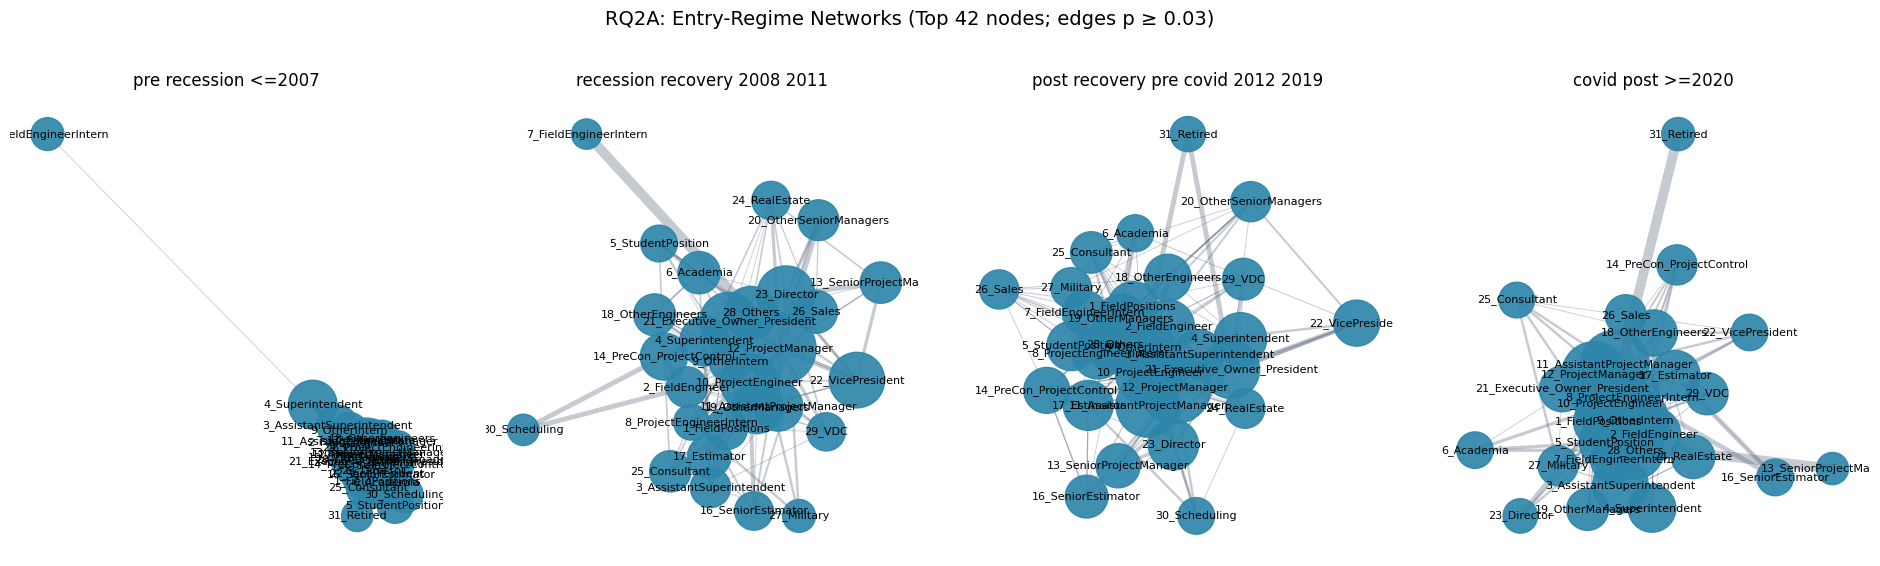

In [7]:
# Entry-regime networks (time only)
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

PATH = "Final_job_timeline_with_detailed_clusters.csv"
ID, ROLE, START, RANK = "id", "detailed_cluster_label", "start_date", "role_rank"
GRAD_YEAR = "graduation_year"

# --- plot style (same vibe you liked)
TOPN = 42
MIN_P = 0.03
ARROW = False
NODE_COLOR, EDGE_COLOR = "#2E86AB", "#5C677D"

def entryRegime(gy):
    if pd.isna(gy):
        return np.nan
    gy = int(gy)
    if gy <= 2007:
        return "pre_recession_<=2007"
    elif 2008 <= gy <= 2011:
        return "recession_recovery_2008_2011"
    elif 2012 <= gy <= 2019:
        return "post_recovery_pre_covid_2012_2019"
    else:
        return "covid_post_>=2020"

df = pd.read_csv(PATH)
df[START] = pd.to_datetime(df[START], errors="coerce")
df = df[~df[ROLE].isna()].copy()
df[GRAD_YEAR] = pd.to_numeric(df.get(GRAD_YEAR, np.nan), errors="coerce")
df["entry_regime"] = df[GRAD_YEAR].apply(entryRegime)

sortCols = [ID, START]
if RANK in df.columns:
    sortCols.append(RANK)
df = df.sort_values(sortCols)

def buildCareerNetwork(data):
    transitions = []
    for pid, g in data.groupby(ID):
        g = g.reset_index(drop=True)
        for i in range(len(g) - 1):
            s, d = g.loc[i, ROLE], g.loc[i + 1, ROLE]
            if pd.isna(s) or pd.isna(d) or s == d:
                continue
            transitions.append((s, d))

    edgeCounts = defaultdict(int)
    for s, d in transitions:
        edgeCounts[(s, d)] += 1

    G = nx.DiGraph()
    for (s, d), w in edgeCounts.items():
        G.add_edge(s, d, weight=float(w))

    for u in G.nodes():
        outW = sum(G[u][v]["weight"] for v in G.successors(u))
        for v in G.successors(u):
            w = G[u][v]["weight"]
            G[u][v]["p"] = (w / outW) if outW > 0 else 0.0
            G[u][v]["distance"] = 1.0 / max(w, 1e-9)
    return G

def giniCoefficient(x):
    x = np.array(list(x), dtype=float)
    if len(x) == 0 or np.sum(x) == 0:
        return 0.0
    x = np.sort(x)
    n = len(x)
    idx = np.arange(1, n + 1)
    return (np.sum((2 * idx - n - 1) * x)) / (n * np.sum(x))

def computeMetrics(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    totalT = float(sum(d["weight"] for _, _, d in G.edges(data=True))) if m else 0.0
    density = nx.density(G) if n > 1 else 0.0
    reciprocity = nx.reciprocity(G) if m > 0 else 0.0

    weights = np.array([d["weight"] for _, _, d in G.edges(data=True)], dtype=float)
    gini = giniCoefficient(weights)
    topCount = max(1, len(weights)//10) if len(weights) else 0
    top10 = (np.sum(np.sort(weights)[-topCount:]) / np.sum(weights) * 100) if topCount and np.sum(weights) else 0.0

    # communities
    modularity, nComms = np.nan, np.nan
    try:
        H = G.to_undirected()
        comms = nx.community.louvain_communities(H, weight="weight", seed=42)
        modularity = nx.community.modularity(H, comms, weight="weight")
        nComms = len(comms)
    except Exception:
        pass

    return dict(nodes=n, edges=m, total_transitions=totalT, density=density, reciprocity=reciprocity,
                gini=gini, top10_share_pct=top10, n_communities=nComms, modularity=modularity)

def topSubgraphByPagerank(G, k, minP):
    if G.number_of_edges() == 0:
        return G.copy(), {n: 0.0 for n in G.nodes()}
    pr = nx.pagerank(G, alpha=0.85, weight="weight")
    keep = set(sorted(G.nodes(), key=lambda n: pr.get(n, 0.0), reverse=True)[:k])
    H = G.subgraph(keep).copy()
    H.remove_edges_from([(u, v) for u, v, d in H.edges(data=True) if d.get("p", 0.0) < minP])
    return H, pr

def drawPreferred(G, pr, seed, title):
    if G.number_of_nodes() == 0:
        plt.gca().set_axis_off()
        plt.title(title)
        return
    pos = nx.spring_layout(G, k=0.8/np.sqrt(max(1, G.number_of_nodes())), iterations=250, seed=seed)
    s = np.array([pr.get(n, 0.0) for n in G.nodes()], float)
    s = 2600 * ((s / (s.max() if s.max() > 0 else 1)) ** 0.55) + 100
    w = [max(0.6, 7.0 * d.get("p", 0.0)) for *_, d in G.edges(data=True)]
    nx.draw_networkx_edges(G, pos, edge_color=EDGE_COLOR, width=w, alpha=0.35, arrows=ARROW)
    nx.draw_networkx_nodes(G, pos, node_color=NODE_COLOR, node_size=s, alpha=0.92)
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.title(title)
    plt.axis("off")

regimes = [
    "pre_recession_<=2007",
    "recession_recovery_2008_2011",
    "post_recovery_pre_covid_2012_2019",
    "covid_post_>=2020",
]

rows = []
nets = {}
for reg in regimes:
    sub = df[df["entry_regime"] == reg]
    G = buildCareerNetwork(sub)
    nets[reg] = G
    met = computeMetrics(G)
    met.update({"entry_regime": reg, "n_people": sub[ID].nunique()})
    rows.append(met)

metricsDf = pd.DataFrame(rows).sort_values("entry_regime").reset_index(drop=True)
print("RQ2A: ENTRY-REGIME NETWORK COMPARISON")
print("="*40)
print(metricsDf[["entry_regime","n_people","nodes","edges","total_transitions","density","reciprocity","gini","top10_share_pct","n_communities","modularity"]].to_string(index=False))

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
plt.subplots_adjust(wspace=0.10)
for i, reg in enumerate(regimes):
    H, pr = topSubgraphByPagerank(nets[reg], TOPN, MIN_P)
    plt.sca(axes[i])
    drawPreferred(H, pr, seed=100+i, title=reg.replace("_", " "))
plt.suptitle(f"RQ2A: Entry-Regime Networks (Top {TOPN} nodes; edges p ≥ {MIN_P})", y=1.02, fontsize=14)
plt.show()


/tmp/ipykernel_1611/3746312065.py:63: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[START] = pd.to_datetime(df[START], errors="coerce")


RQ2A: ENTRY-REGIME NETWORK COMPARISON
                     entry_regime  n_people  nodes  edges  total_transitions  density  reciprocity     gini  top10_share_pct  n_communities  modularity
                covid_post_>=2020       367     28    266             1093.0 0.351852     0.676692 0.605580        52.241537              3    0.131127
post_recovery_pre_covid_2012_2019       471     30    364             1687.0 0.418391     0.686813 0.620213        52.874926              3    0.227204
             pre_recession_<=2007       194     30    217              526.0 0.249425     0.589862 0.455082        38.212928              4    0.168863
     recession_recovery_2008_2011       147     29    222              467.0 0.273399     0.513514 0.419806        37.901499              5    0.165875


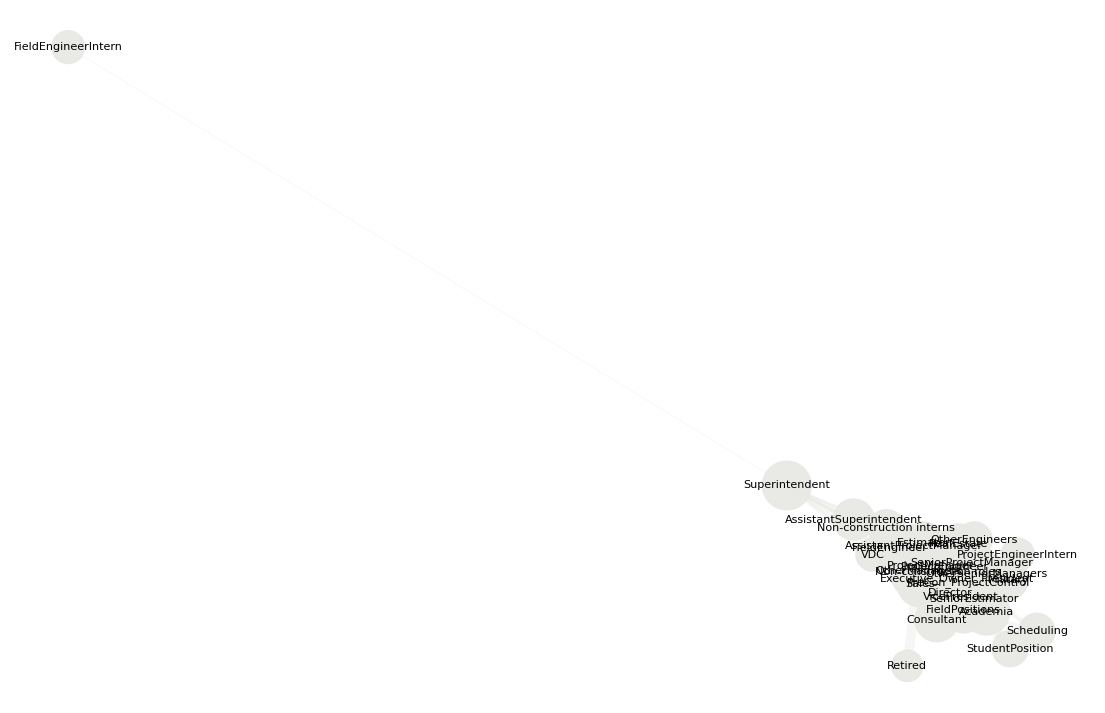

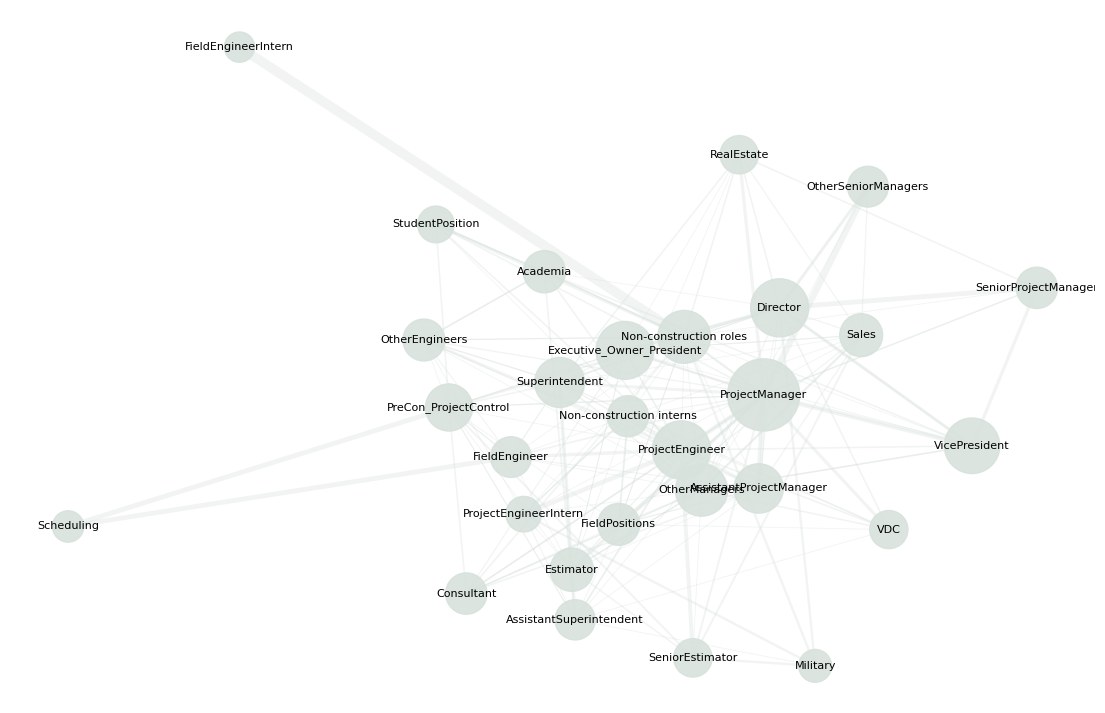

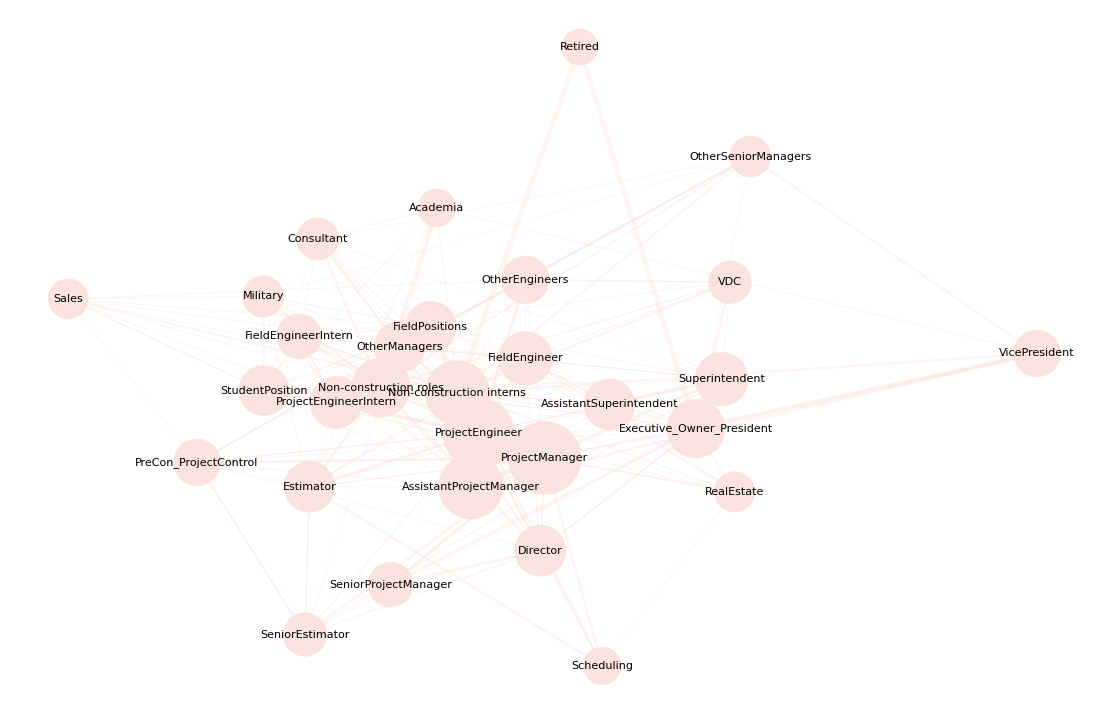

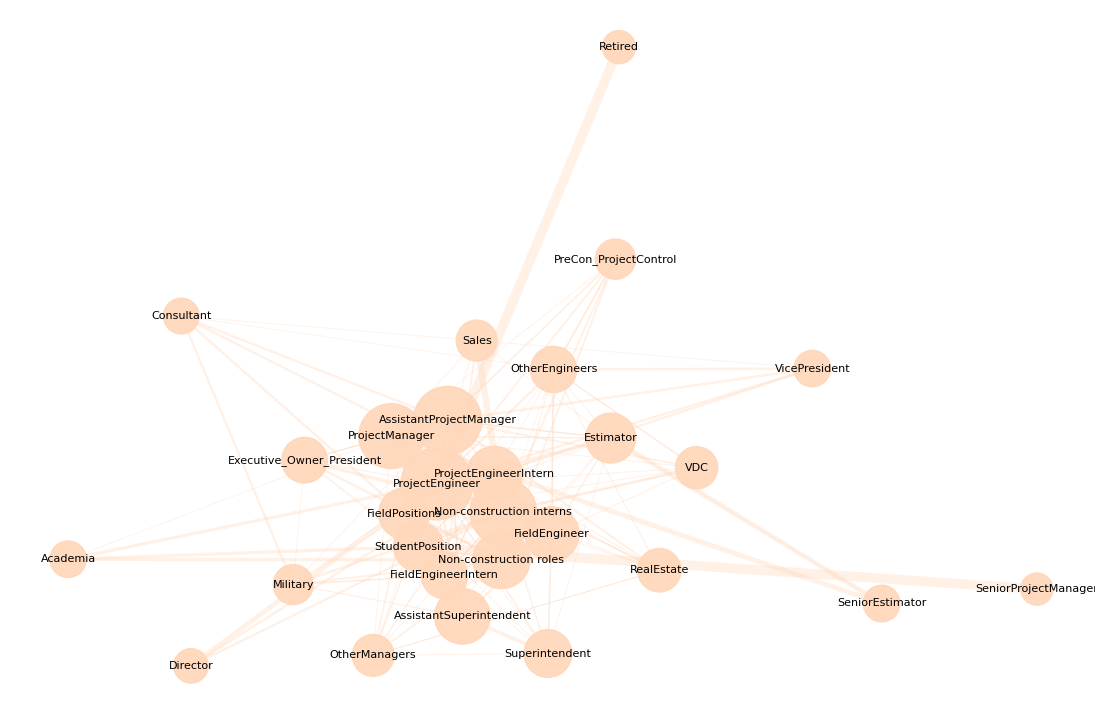

In [8]:
# Entry-regime networks
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import re

PATH = "Final_job_timeline_with_detailed_clusters.csv"
ID, ROLE, START, RANK = "id", "detailed_cluster_label", "start_date", "role_rank"
GRAD_YEAR = "graduation_year"

# --- plot style
TOPN = 42
MIN_P = 0.03
ARROW = False

# pastel colors for the 4 regimes (node = edge)
COLORS = ["#e8e8e4", "#d8e2dc", "#fae1dd", "#ffd7ba"]

# -----------------------------
# label cleaning + renaming (ONLY for figures)
# -----------------------------
def stripPrefix(name):
    s = str(name)
    s = re.sub(r"^\d+_", "", s)
    s = re.sub(r"^_", "", s)
    return s

def renameForFigure(name):
    s = stripPrefix(name)
    sLower = s.strip().lower()
    compact = re.sub(r"[\s_]+", "", sLower)

    if sLower == "others":
        return "Non-construction roles"

    if compact in {"otherintern", "otherinterns", "othersintern", "othersinterns"}:
        return "Non-construction interns"

    return s

# -----------------------------
# entry regimes
# -----------------------------
def entryRegime(gy):
    if pd.isna(gy):
        return np.nan
    gy = int(gy)
    if gy <= 2007:
        return "pre_recession_<=2007"
    elif 2008 <= gy <= 2011:
        return "recession_recovery_2008_2011"
    elif 2012 <= gy <= 2019:
        return "post_recovery_pre_covid_2012_2019"
    else:
        return "covid_post_>=2020"

# -----------------------------
# load + prep
# -----------------------------
df = pd.read_csv(PATH)
df[START] = pd.to_datetime(df[START], errors="coerce")
df = df[~df[ROLE].isna()].copy()
df[GRAD_YEAR] = pd.to_numeric(df.get(GRAD_YEAR, np.nan), errors="coerce")
df["entry_regime"] = df[GRAD_YEAR].apply(entryRegime)

sortCols = [ID, START]
if RANK in df.columns:
    sortCols.append(RANK)
df = df.sort_values(sortCols)

# -----------------------------
# build network
# -----------------------------
def buildCareerNetwork(data):
    transitions = []
    for pid, g in data.groupby(ID):
        g = g.reset_index(drop=True)
        for i in range(len(g) - 1):
            s, d = g.loc[i, ROLE], g.loc[i + 1, ROLE]
            if pd.isna(s) or pd.isna(d) or s == d:
                continue
            transitions.append((s, d))

    edgeCounts = defaultdict(int)
    for s, d in transitions:
        edgeCounts[(s, d)] += 1

    G = nx.DiGraph()
    for (s, d), w in edgeCounts.items():
        G.add_edge(s, d, weight=float(w))

    for u in G.nodes():
        outW = sum(G[u][v]["weight"] for v in G.successors(u))
        for v in G.successors(u):
            w = G[u][v]["weight"]
            G[u][v]["p"] = (w / outW) if outW > 0 else 0.0
            G[u][v]["distance"] = 1.0 / max(w, 1e-9)
    return G

# -----------------------------
# metrics
# -----------------------------
def giniCoefficient(x):
    x = np.array(list(x), dtype=float)
    if len(x) == 0 or np.sum(x) == 0:
        return 0.0
    x = np.sort(x)
    n = len(x)
    idx = np.arange(1, n + 1)
    return (np.sum((2 * idx - n - 1) * x)) / (n * np.sum(x))

def computeMetrics(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    totalT = float(sum(d["weight"] for _, _, d in G.edges(data=True))) if m else 0.0
    density = nx.density(G) if n > 1 else 0.0
    reciprocity = nx.reciprocity(G) if m > 0 else 0.0

    weights = np.array([d["weight"] for _, _, d in G.edges(data=True)], dtype=float)
    gini = giniCoefficient(weights)
    topCount = max(1, len(weights)//10) if len(weights) else 0
    top10 = (np.sum(np.sort(weights)[-topCount:]) / np.sum(weights) * 100) if topCount and np.sum(weights) else 0.0

    modularity, nComms = np.nan, np.nan
    try:
        H = G.to_undirected()
        comms = nx.community.louvain_communities(H, weight="weight", seed=42)
        modularity = nx.community.modularity(H, comms, weight="weight")
        nComms = len(comms)
    except Exception:
        pass

    return dict(nodes=n, edges=m, total_transitions=totalT, density=density,
                reciprocity=reciprocity, gini=gini, top10_share_pct=top10,
                n_communities=nComms, modularity=modularity)

# -----------------------------
# top PageRank subgraph
# -----------------------------
def topSubgraphByPagerank(G, k, minP):
    if G.number_of_edges() == 0:
        return G.copy(), {n: 0.0 for n in G.nodes()}
    pr = nx.pagerank(G, alpha=0.85, weight="weight")
    keep = set(sorted(G.nodes(), key=lambda n: pr.get(n, 0.0), reverse=True)[:k])
    H = G.subgraph(keep).copy()
    H.remove_edges_from([(u, v) for u, v, d in H.edges(data=True) if d.get("p", 0.0) < minP])
    return H, pr

# -----------------------------
# draw
# -----------------------------
def drawPreferredClean(G, pr, seed, edgeColor, nodeColor, outPrefix):
    fig, ax = plt.subplots(figsize=(14, 9))

    if G.number_of_nodes() == 0:
        ax.set_axis_off()
        fig.savefig(f"{outPrefix}.png", dpi=400, bbox_inches="tight", pad_inches=0.02)
        fig.savefig(f"{outPrefix}.pdf", bbox_inches="tight", pad_inches=0.02)
        plt.show()
        return

    pos = nx.spring_layout(G, k=0.8/np.sqrt(max(1, G.number_of_nodes())), iterations=250, seed=seed)

    s = np.array([pr.get(n, 0.0) for n in G.nodes()], float)
    s = 2600 * ((s / (s.max() if s.max() > 0 else 1)) ** 0.55) + 100

    w = [max(0.6, 7.0 * d.get("p", 0.0)) for *_, d in G.edges(data=True)]

    nx.draw_networkx_edges(G, pos, edge_color=edgeColor, width=w, alpha=0.35, arrows=ARROW, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_color=nodeColor, node_size=s, alpha=0.92, ax=ax)

    labels = {n: renameForFigure(n) for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, ax=ax)

    ax.axis("off")
    ax.margins(0)

    # tight crop
    xs = np.array([pos[n][0] for n in G.nodes()])
    ys = np.array([pos[n][1] for n in G.nodes()])
    xpad = 0.06 * (xs.max() - xs.min() + 1e-9)
    ypad = 0.06 * (ys.max() - ys.min() + 1e-9)
    ax.set_xlim(xs.min() - xpad, xs.max() + xpad)
    ax.set_ylim(ys.min() - ypad, ys.max() + ypad)

    fig.savefig(f"{outPrefix}.png", dpi=400, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(f"{outPrefix}.pdf", bbox_inches="tight", pad_inches=0.02)
    plt.show()

# -----------------------------
# run
# -----------------------------
regimes = [
    "pre_recession_<=2007",
    "recession_recovery_2008_2011",
    "post_recovery_pre_covid_2012_2019",
    "covid_post_>=2020",
]

rows = []
nets = {}

for reg in regimes:
    sub = df[df["entry_regime"] == reg]
    G = buildCareerNetwork(sub)
    nets[reg] = G
    met = computeMetrics(G)
    met.update({"entry_regime": reg, "n_people": sub[ID].nunique()})
    rows.append(met)

metricsDf = pd.DataFrame(rows).sort_values("entry_regime").reset_index(drop=True)

print("RQ2A: ENTRY-REGIME NETWORK COMPARISON")
print("="*40)
print(metricsDf[["entry_regime","n_people","nodes","edges","total_transitions",
                 "density","reciprocity","gini","top10_share_pct",
                 "n_communities","modularity"]].to_string(index=False))

# --- draw 4 separate figures
for i, reg in enumerate(regimes):
    H, pr = topSubgraphByPagerank(nets[reg], TOPN, MIN_P)
    drawPreferredClean(
        H, pr,
        seed=100+i,
        edgeColor=COLORS[i],
        nodeColor=COLORS[i],
        outPrefix=f"RQ2A_{reg}"
    )


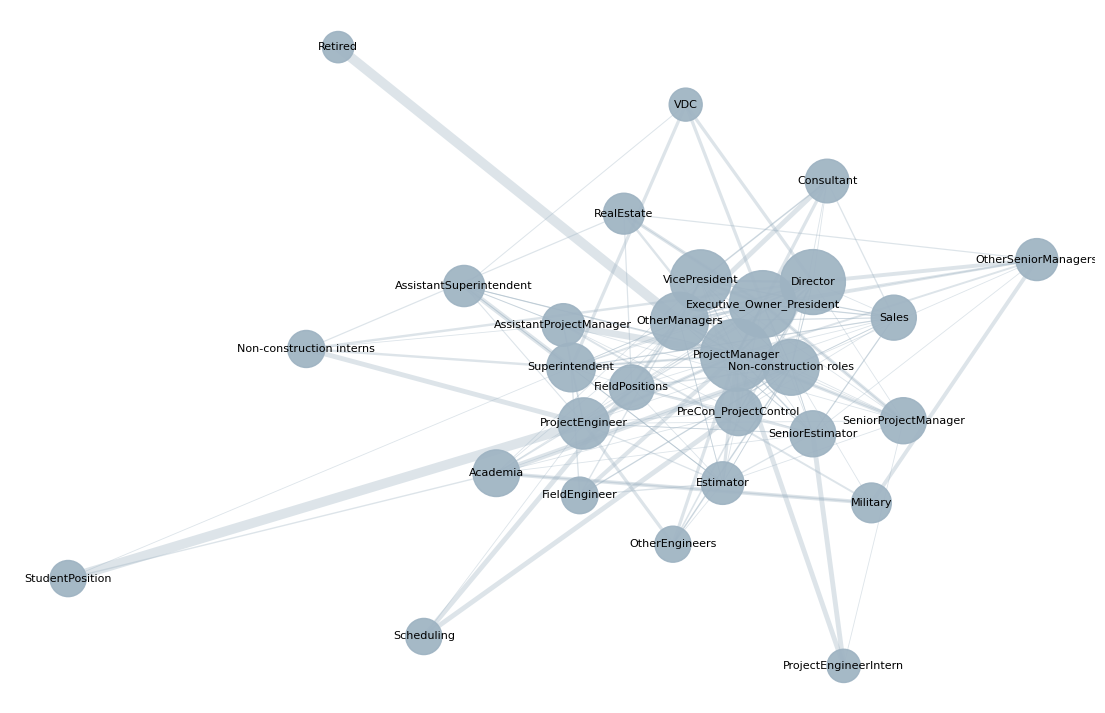

In [9]:
# Clean pre-recession figure

def draw_preRecession_without_isolate(reg="pre_recession_<=2007",
                                      seed=100,
                                      color="#9eb3c2",
                                      outPrefix="RQ2A_pre_recession_clean",
                                      removeLabelClean="FieldEngineerIntern"):

    # build same top subgraph
    H, pr = topSubgraphByPagerank(nets[reg], TOPN, MIN_P)

    if H.number_of_nodes() == 0:
        print("Empty graph")
        return

    # identify node to remove by CLEAN label
    rename = {n: renameForFigure(n) for n in H.nodes()}
    removeNodes = [n for n, lab in rename.items() if lab == removeLabelClean]

    # remove ONLY for plotting
    H_plot = H.copy()
    H_plot.remove_nodes_from(removeNodes)

    # same layout
    pos = nx.spring_layout(
        H_plot,
        k=0.8 / np.sqrt(max(1, H_plot.number_of_nodes())),
        iterations=250,
        seed=seed
    )

    s = np.array([pr.get(n, 0.0) for n in H_plot.nodes()], float)
    s = 2600 * ((s / (s.max() if s.max() > 0 else 1)) ** 0.55) + 100
    w = [max(0.6, 7.0 * d.get("p", 0.0)) for *_, d in H_plot.edges(data=True)]

    fig, ax = plt.subplots(figsize=(14, 9))

    nx.draw_networkx_edges(H_plot, pos, edge_color=color, width=w, alpha=0.35, arrows=False, ax=ax)
    nx.draw_networkx_nodes(H_plot, pos, node_color=color, node_size=s, alpha=0.92, ax=ax)

    labels = {n: renameForFigure(n) for n in H_plot.nodes()}
    nx.draw_networkx_labels(H_plot, pos, labels=labels, font_size=8, ax=ax)

    ax.axis("off")
    ax.margins(0)

    xs = np.array([pos[n][0] for n in H_plot.nodes()])
    ys = np.array([pos[n][1] for n in H_plot.nodes()])
    xpad = 0.06 * (xs.max() - xs.min() + 1e-9)
    ypad = 0.06 * (ys.max() - ys.min() + 1e-9)
    ax.set_xlim(xs.min() - xpad, xs.max() + xpad)
    ax.set_ylim(ys.min() - ypad, ys.max() + ypad)

    fig.savefig(f"{outPrefix}.png", dpi=400, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(f"{outPrefix}.pdf", bbox_inches="tight", pad_inches=0.02)

    plt.show()

draw_preRecession_without_isolate()


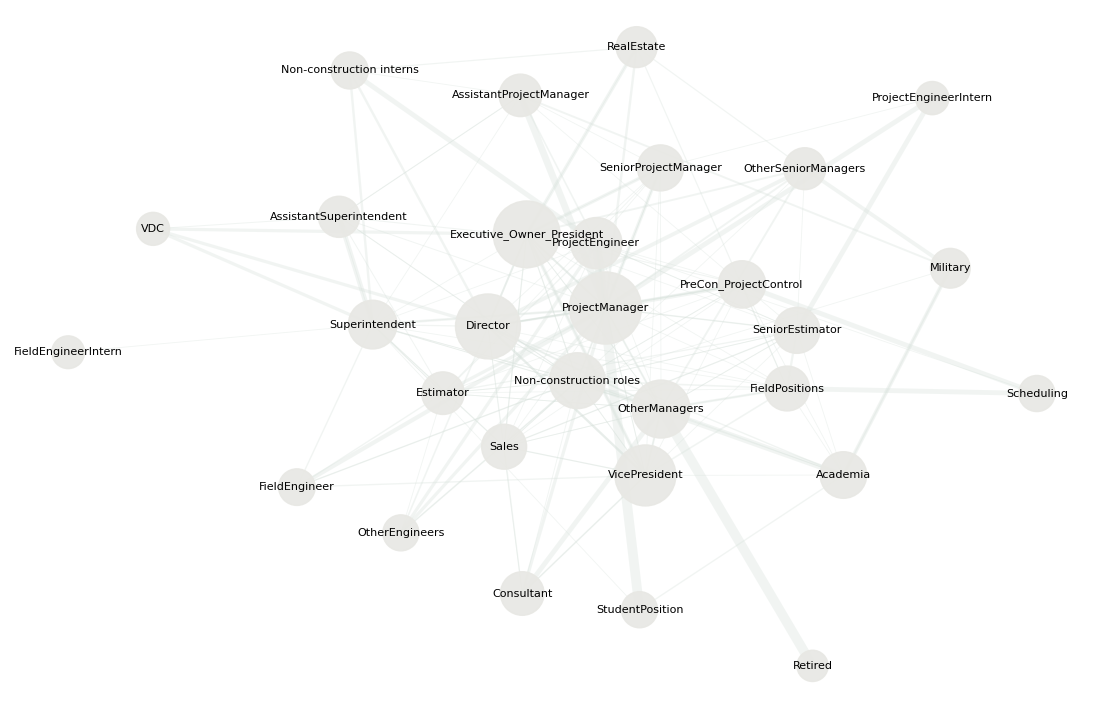

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

NODE_COLOR = "#e8e8e4"
EDGE_COLOR = "#d8e2dc"

reg = "pre_recession_<=2007"
H, pr = topSubgraphByPagerank(nets[reg], TOPN, MIN_P)

fig, ax = plt.subplots(figsize=(14, 9))

if H.number_of_nodes() == 0:
    ax.set_axis_off()
else:
    # 1) drop extreme layout-stretching nodes (figure-only) by focusing on the largest WCC
    wccs = list(nx.weakly_connected_components(H))
    coreNodes = max(wccs, key=len) if wccs else set()
    Hcore = H.subgraph(coreNodes).copy()

    # 2) use a repulsive layout that spreads labels (Kamada-Kawai tends to "unknot" sparse graphs)
    # start positions from spring for stability, then refine with kamada-kawai
    pos0 = nx.spring_layout(Hcore, seed=100, k=1.2/np.sqrt(max(1, Hcore.number_of_nodes())), iterations=400)
    pos = nx.kamada_kawai_layout(Hcore, pos=pos0, weight=None)

    # 3) draw (same sizing logic as your style)
    s = np.array([pr.get(n, 0.0) for n in Hcore.nodes()], float)
    s = 2600 * ((s / (s.max() if s.max() > 0 else 1)) ** 0.55) + 100
    w = [max(0.6, 7.0 * d.get("p", 0.0)) for *_, d in Hcore.edges(data=True)]

    nx.draw_networkx_edges(Hcore, pos, edge_color=EDGE_COLOR, width=w, alpha=0.35, arrows=ARROW, ax=ax)
    nx.draw_networkx_nodes(Hcore, pos, node_color=NODE_COLOR, node_size=s, alpha=0.92, ax=ax)

    labels = {n: renameForFigure(n) for n in Hcore.nodes()}
    nx.draw_networkx_labels(Hcore, pos, labels=labels, font_size=8, ax=ax)

    ax.axis("off")
    ax.margins(0)

    # tight crop (same 0.06 padding)
    xs = np.array([pos[n][0] for n in Hcore.nodes()])
    ys = np.array([pos[n][1] for n in Hcore.nodes()])
    xpad = 0.06 * (xs.max() - xs.min() + 1e-9)
    ypad = 0.06 * (ys.max() - ys.min() + 1e-9)
    ax.set_xlim(xs.min() - xpad, xs.max() + xpad)
    ax.set_ylim(ys.min() - ypad, ys.max() + ypad)

fig.savefig("RQ2A_pre_recession_ONLY_clean.png", dpi=400, bbox_inches="tight", pad_inches=0.02)
fig.savefig("RQ2A_pre_recession_ONLY_clean.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()


In [11]:
#Early vs Mid Career Influence
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.metrics import mutual_info_score, normalized_mutual_info_score
from sklearn.preprocessing import LabelEncoder

# ID, ROLE, START = "id", "detailed_cluster_label", "start_date"

LEADERSHIP_ROLES = {
    "12_ProjectManager", "13_SeniorProjectManager", "19_OtherManagers",
    "20_OtherSeniorManagers", "21_Executive_Owner_President",
    "22_VicePresident", "23_Director"
}

def run_length_compress(seq):
    out, prev = [], None
    for x in seq:
        if pd.isna(x):
            continue
        if x != prev:
            out.append(x)
        prev = x
    return out

def make_signature(roles):
    roles = run_length_compress(roles)
    return "|".join(roles) if roles else ""

def compute_mi_nmi(signatures, outcomes):
    if len(set(signatures)) < 2 or len(set(outcomes)) < 2:
        return 0.0, 0.0

    le_sig = LabelEncoder()
    le_out = LabelEncoder()
    X = le_sig.fit_transform(signatures)
    Y = le_out.fit_transform(outcomes)

    mi = mutual_info_score(X, Y)
    nmi = normalized_mutual_info_score(X, Y)
    return float(mi), float(nmi)

def rq3_position_based_stable_roles(df, min_years=1.0, min_stable_roles=3, show_top=12):
    """
    Scientific RQ3:
      - 'Stable roles' defined by objective tenure threshold (>= min_years), estimated as time to next role start.
      - Early = first stable role; Mid = intermediate stable roles; Final = last stable role.
      - No explicit label/category exclusions.
    """
    d = df.copy()
    d[START] = pd.to_datetime(d[START], errors="coerce")
    d = d.dropna(subset=[ID, ROLE, START]).sort_values([ID, START])

    careers = []
    dropped_short = 0
    total_roles_considered = 0
    stable_roles_kept = 0

    for pid, g in d.groupby(ID):
        g = g.sort_values(START).reset_index(drop=True)
        if len(g) < 2:
            continue

        next_start = g[START].shift(-1)
        tenure_years = (next_start - g[START]).dt.days / 365.25

        # Count stats (tenure only defined where next_start exists)
        valid_tenure = tenure_years.notna()
        total_roles_considered += int(valid_tenure.sum())
        dropped_short += int(((tenure_years < min_years) & valid_tenure).sum())

        stable_mask = (tenure_years >= min_years)
        stable_roles = g.loc[stable_mask, ROLE].tolist()
        stable_roles_kept += len(stable_roles)

        if len(stable_roles) < min_stable_roles:
            continue

        early = [stable_roles[0]]
        final = stable_roles[-1]
        mid = stable_roles[1:-1]

        if len(mid) == 0:
            continue

        careers.append({"pid": pid, "early": early, "mid": mid, "final": final, "k": len(stable_roles)})

    n = len(careers)
    print("=" * 80)
    print(f"RQ3 – Position-based influence using STABLE roles (tenure >= {min_years:.1f} year)")
    print("=" * 80)
    print(f"N careers analyzed (need >= {min_stable_roles} stable roles and >=1 mid): {n}")

    if total_roles_considered > 0:
        print(f"\nTenure filter impact (objective, no label exclusions):")
        print(f"  Role episodes with measurable tenure: {total_roles_considered}")
        print(f"  Dropped for tenure < {min_years:.1f}y: {dropped_short} ({(dropped_short/total_roles_considered)*100:.1f}%)")
        print(f"  Kept as stable roles: {stable_roles_kept} ({(stable_roles_kept/total_roles_considered)*100:.1f}%)")

    if n < 50:
        print("\nToo few careers after filtering. Try min_years=0.75 or min_stable_roles=2.")
        return None

    early_sigs = [make_signature(c["early"]) for c in careers]
    mid_sigs = [make_signature(c["mid"]) for c in careers]
    finals = [c["final"] for c in careers]

    early_mi, early_nmi = compute_mi_nmi(early_sigs, finals)
    mid_mi, mid_nmi = compute_mi_nmi(mid_sigs, finals)

    print("\nFinal role outcome (last stable role):")
    print(f"  Early (first stable role) MI: {early_mi:6.3f} | NMI: {early_nmi:5.3f}")
    print(f"  Mid   (stable intermediates) MI: {mid_mi:6.3f} | NMI: {mid_nmi:5.3f}")
    print(f"  Comparison (NMI): {'MID stronger' if mid_nmi > early_nmi else 'EARLY stronger'} by {abs(mid_nmi-early_nmi):.3f}")

    # Leadership collapsed outcome
    lead_outcomes = ["Leadership" if f in LEADERSHIP_ROLES else "Non-Leadership" for f in finals]
    e_mi_L, e_nmi_L = compute_mi_nmi(early_sigs, lead_outcomes)
    m_mi_L, m_nmi_L = compute_mi_nmi(mid_sigs, lead_outcomes)

    print("\nLeadership (collapsed) outcome:")
    print(f"  Early → Leadership MI: {e_mi_L:6.3f} | NMI: {e_nmi_L:5.3f}")
    print(f"  Mid   → Leadership MI: {m_mi_L:6.3f} | NMI: {m_nmi_L:5.3f}")
    print(f"  Comparison (NMI): {'MID stronger' if m_nmi_L > e_nmi_L else 'EARLY stronger'} by {abs(m_nmi_L-e_nmi_L):.3f}")

    # Show most frequent patterns
    def show_patterns(stage_sigs, outcomes, label):
        pairs = list(zip(stage_sigs, outcomes))
        ctr = Counter(pairs).most_common(show_top)
        print(f"\nMost frequent {label} → FINAL patterns:")
        for (sig, out), cnt in ctr:
            if cnt < 3:
                continue
            disp = sig.replace("|", " → ") if sig else "(empty)"
            print(f"  {cnt:3d} people: {disp} → {out}")

    show_patterns(early_sigs, finals, "EARLY")
    show_patterns(mid_sigs, finals, "MID")

    return {
        "n_careers": n,
        "early_nmi": early_nmi,
        "mid_nmi": mid_nmi,
        "early_lead_nmi": e_nmi_L,
        "mid_lead_nmi": m_nmi_L,
    }

results_rq3 = rq3_position_based_stable_roles(df, min_years=1.0, min_stable_roles=3)


RQ3 – Position-based influence using STABLE roles (tenure >= 1.0 year)
N careers analyzed (need >= 3 stable roles and >=1 mid): 648

Tenure filter impact (objective, no label exclusions):
  Role episodes with measurable tenure: 5096
  Dropped for tenure < 1.0y: 1868 (36.7%)
  Kept as stable roles: 3228 (63.3%)

Final role outcome (last stable role):
  Early (first stable role) MI:  0.537 | NMI: 0.198
  Mid   (stable intermediates) MI:  1.742 | NMI: 0.480
  Comparison (NMI): MID stronger by 0.283

Leadership (collapsed) outcome:
  Early → Leadership MI:  0.106 | NMI: 0.064
  Mid   → Leadership MI:  0.397 | NMI: 0.155
  Comparison (NMI): MID stronger by 0.091

Most frequent EARLY → FINAL patterns:
   29 people: 9_OtherIntern → 10_ProjectEngineer
   24 people: 9_OtherIntern → 12_ProjectManager
   24 people: 28_Others → 10_ProjectEngineer
   24 people: 10_ProjectEngineer → 12_ProjectManager
   19 people: 9_OtherIntern → 11_AssistantProjectManager
   14 people: 28_Others → 11_AssistantProje

In [12]:
# FINAL VERSION
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.metrics import mutual_info_score, normalized_mutual_info_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

LEADERSHIP_STRICT = {
    "13_SeniorProjectManager",
    "19_OtherManagers", "20_OtherSeniorManagers",
    "21_Executive_Owner_President", "22_VicePresident", "23_Director"
}

def run_length_compress(seq):
    out, prev = [], None
    for x in seq:
        if pd.isna(x):
            continue
        if x != prev:
            out.append(x)
        prev = x
    return out

def make_signature(roles):
    roles = run_length_compress(roles)
    return "|".join(roles) if roles else ""

def compute_mi_nmi(signatures, outcomes):
    if len(set(signatures)) < 2 or len(set(outcomes)) < 2:
        return 0.0, 0.0

    le_sig = LabelEncoder()
    le_out = LabelEncoder()
    X = le_sig.fit_transform(signatures)
    Y = le_out.fit_transform(outcomes)

    mi = mutual_info_score(X, Y)
    nmi = normalized_mutual_info_score(X, Y)
    return float(mi), float(nmi)

def rq3_final_with_controls(df, min_years=1.0, min_stable_roles=3, show_top=12):

    d = df.copy()
    d[START] = pd.to_datetime(d[START], errors="coerce")
    d = d.dropna(subset=[ID, ROLE, START]).sort_values([ID, START])

    careers = []
    total_roles = 0
    dropped_short = 0
    stable_kept = 0

    for pid, g in d.groupby(ID):
        g = g.sort_values(START).reset_index(drop=True)

        if len(g) < 2:
            continue

        next_start = g[START].shift(-1)
        next_start.iloc[-1] = pd.Timestamp.now()  # Use current date for final role

        tenure_years = (next_start - g[START]).dt.days / 365.25

        valid_tenure = tenure_years.notna()
        total_roles += int(valid_tenure.sum())
        dropped_short += int(((tenure_years < min_years) & valid_tenure).sum())

        stable_mask = (tenure_years >= min_years)
        stable_roles = g.loc[stable_mask, ROLE].tolist()
        stable_dates = g.loc[stable_mask, START].tolist()
        stable_kept += len(stable_roles)

        if len(stable_roles) < min_stable_roles:
            continue

        early_roles = [stable_roles[0]]
        early_date = stable_dates[0]
        final_role = stable_roles[-1]
        final_date = stable_dates[-1]
        mid_roles = stable_roles[1:-1]

        if len(mid_roles) == 0:
            continue

        mid_dates = stable_dates[1:-1]
        mid_centroid = pd.Timestamp(int(np.mean([d.value for d in mid_dates])))

        early_to_final = (final_date - early_date).days / 365.25
        mid_to_final = (final_date - mid_centroid).days / 365.25

        careers.append({
            "pid": pid,
            "early": early_roles,
            "mid": mid_roles,
            "final": final_role,
            "k": len(stable_roles),
            "early_to_final_years": early_to_final,
            "mid_to_final_years": mid_to_final,
            "career_length": early_to_final  # Total career span
        })

    n = len(careers)

    print("=" * 80)
    print("RQ3 – FINAL ANALYSIS WITH TEMPORAL PROXIMITY CONTROL")
    print("=" * 80)
    print(f"Total careers analyzed: {n}")
    print()

    # ====================
    # OVERALL (UNCONTROLLED)
    # ====================
    early_sigs = [make_signature(c["early"]) for c in careers]
    mid_sigs = [make_signature(c["mid"]) for c in careers]
    finals = [c["final"] for c in careers]

    early_mi, early_nmi = compute_mi_nmi(early_sigs, finals)
    mid_mi, mid_nmi = compute_mi_nmi(mid_sigs, finals)

    early_dists = [c['early_to_final_years'] for c in careers]
    mid_dists = [c['mid_to_final_years'] for c in careers]

    print("OVERALL RESULTS (no controls):")
    print(f"  Sample: {n} careers")
    print(f"  Early → Final NMI: {early_nmi:.3f} (mean distance: {np.mean(early_dists):.1f}y)")
    print(f"  Mid   → Final NMI: {mid_nmi:.3f} (mean distance: {np.mean(mid_dists):.1f}y)")
    print(f"  Raw advantage for mid-career: +{mid_nmi - early_nmi:.3f}")
    print(f"  Temporal confound: Mid-career is {np.mean(early_dists) - np.mean(mid_dists):.1f}y closer")
    print()

    # ====================
    # STRATIFIED ANALYSIS
    # ====================
    print("STRATIFIED BY CAREER LENGTH (controlling for temporal proximity):")
    print("-" * 80)

    # Create quartiles based on career length
    career_lengths = [c['career_length'] for c in careers]
    quartiles = np.percentile(career_lengths, [25, 50, 75])

    strata_results = []

    for i in range(4):
        if i == 0:
            label = f"Q1 (shortest: ≤{quartiles[0]:.1f}y)"
            mask = [c['career_length'] <= quartiles[0] for c in careers]
        elif i == 1:
            label = f"Q2 ({quartiles[0]:.1f}-{quartiles[1]:.1f}y)"
            mask = [(c['career_length'] > quartiles[0]) & (c['career_length'] <= quartiles[1]) for c in careers]
        elif i == 2:
            label = f"Q3 ({quartiles[1]:.1f}-{quartiles[2]:.1f}y)"
            mask = [(c['career_length'] > quartiles[1]) & (c['career_length'] <= quartiles[2]) for c in careers]
        else:
            label = f"Q4 (longest: >{quartiles[2]:.1f}y)"
            mask = [c['career_length'] > quartiles[2] for c in careers]

        stratum_careers = [c for c, m in zip(careers, mask) if m]

        if len(stratum_careers) < 30:
            continue

        s_early_sigs = [make_signature(c["early"]) for c in stratum_careers]
        s_mid_sigs = [make_signature(c["mid"]) for c in stratum_careers]
        s_finals = [c["final"] for c in stratum_careers]

        s_early_mi, s_early_nmi = compute_mi_nmi(s_early_sigs, s_finals)
        s_mid_mi, s_mid_nmi = compute_mi_nmi(s_mid_sigs, s_finals)

        s_early_dists = [c['early_to_final_years'] for c in stratum_careers]
        s_mid_dists = [c['mid_to_final_years'] for c in stratum_careers]

        diff = s_mid_nmi - s_early_nmi

        print(f"\n{label}")
        print(f"  n = {len(stratum_careers)}")
        print(f"  Mean career length: {np.mean([c['career_length'] for c in stratum_careers]):.1f}y")
        print(f"  Early distance: {np.mean(s_early_dists):.1f}y | Mid distance: {np.mean(s_mid_dists):.1f}y")
        print(f"  Early NMI: {s_early_nmi:.3f} | Mid NMI: {s_mid_nmi:.3f}")
        print(f"  Mid-career advantage: {diff:+.3f} ({'PERSISTS' if diff > 0.05 else 'weak/none'})")

        strata_results.append({
            'quartile': i+1,
            'label': label,
            'n': len(stratum_careers),
            'career_length': np.mean([c['career_length'] for c in stratum_careers]),
            'early_nmi': s_early_nmi,
            'mid_nmi': s_mid_nmi,
            'diff': diff,
            'time_gap': np.mean(s_early_dists) - np.mean(s_mid_dists)
        })

    print("\n" + "=" * 80)
    print("INTERPRETATION:")
    print("-" * 80)

    # Check if mid-career advantage persists across strata
    strong_strata = sum(1 for s in strata_results if s['diff'] > 0.05)

    if strong_strata >= 3:
        print("✓ Mid-career advantage PERSISTS across career length strata")
        print("  → Finding appears robust beyond temporal proximity")
    elif strong_strata >= 2:
        print("⚠ Mid-career advantage MIXED across strata")
        print("  → Temporal proximity partially explains the effect")
    else:
        print("✗ Mid-career advantage WEAK when controlling for career length")
        print("  → Temporal proximity may fully explain the raw difference")

    print()

    # ====================
    # LEADERSHIP ANALYSIS
    # ====================
    lead_outcomes = ["Leadership" if f in LEADERSHIP_STRICT else "Non-Leadership" for f in finals]
    n_leaders = sum(1 for x in lead_outcomes if x == "Leadership")

    e_mi_L, e_nmi_L = compute_mi_nmi(early_sigs, lead_outcomes)
    m_mi_L, m_nmi_L = compute_mi_nmi(mid_sigs, lead_outcomes)

    print(f"LEADERSHIP OUTCOMES ({n_leaders}/{n} = {n_leaders/n*100:.1f}% in leadership):")
    print(f"  Early → Leadership NMI: {e_nmi_L:.3f}")
    print(f"  Mid   → Leadership NMI: {m_nmi_L:.3f}")
    print(f"  Difference: {m_nmi_L - e_nmi_L:+.3f}")
    print()

    # ====================
    # COMMON PATTERNS
    # ====================
    def show_patterns(stage_sigs, outcomes, label, top_n=10):
        pairs = list(zip(stage_sigs, outcomes))
        ctr = Counter(pairs).most_common(top_n)
        print(f"{label} → FINAL (top {top_n}):")
        for (sig, out), cnt in ctr:
            if cnt < 5:
                continue
            disp = sig.replace("|", " → ") if sig else "(empty)"
            print(f"  {cnt:3d}: {disp} → {out}")
        print()

    show_patterns(early_sigs, finals, "EARLY")
    show_patterns(mid_sigs, finals, "MID")

    return {
        "n": n,
        "overall": {
            "early_nmi": early_nmi,
            "mid_nmi": mid_nmi,
            "diff": mid_nmi - early_nmi
        },
        "strata": strata_results,
        "leadership": {
            "early_nmi": e_nmi_L,
            "mid_nmi": m_nmi_L,
            "diff": m_nmi_L - e_nmi_L,
            "n_leaders": n_leaders
        }
    }

# ============================
# RUN ANALYSIS
# ============================
results = rq3_final_with_controls(df, min_years=1.0, min_stable_roles=3)

RQ3 – FINAL ANALYSIS WITH TEMPORAL PROXIMITY CONTROL
Total careers analyzed: 891

OVERALL RESULTS (no controls):
  Sample: 891 careers
  Early → Final NMI: 0.157 (mean distance: 10.0y)
  Mid   → Final NMI: 0.476 (mean distance: 4.9y)
  Raw advantage for mid-career: +0.320
  Temporal confound: Mid-career is 5.1y closer

STRATIFIED BY CAREER LENGTH (controlling for temporal proximity):
--------------------------------------------------------------------------------

Q1 (shortest: ≤6.1y)
  n = 226
  Mean career length: 4.7y
  Early distance: 4.7y | Mid distance: 2.4y
  Early NMI: 0.310 | Mid NMI: 0.497
  Mid-career advantage: +0.187 (PERSISTS)

Q2 (6.1-8.7y)
  n = 223
  Mean career length: 7.4y
  Early distance: 7.4y | Mid distance: 3.7y
  Early NMI: 0.259 | Mid NMI: 0.559
  Mid-career advantage: +0.301 (PERSISTS)

Q3 (8.7-12.6y)
  n = 220
  Mean career length: 10.5y
  Early distance: 10.5y | Mid distance: 5.2y
  Early NMI: 0.295 | Mid NMI: 0.585
  Mid-career advantage: +0.290 (PERSISTS)


In [14]:
# Aggregate time spent in same role across different companies
def get_role_transitions_with_aggregated_time(df):
    transitions = []

    for person_id in df['id'].unique():
        person_data = df[df['id'] == person_id].sort_values('role_rank', ascending=False)  # Most recent first

        # Group consecutive same roles together
        role_periods = []
        current_role = None
        current_total_days = 0
        current_companies = []

        for _, row in person_data.iterrows():
            role = row['detailed_cluster_label']
            days = row['days_in_role'] if pd.notna(row['days_in_role']) else 0
            company = row['company']

            if role == current_role:
                # Same role, add to current period
                current_total_days += days
                current_companies.append(company)
            else:
                # Different role, save previous period and start new one
                if current_role is not None:
                    role_periods.append({
                        'role': current_role,
                        'total_days': current_total_days,
                        'companies': current_companies,
                        'cohort': row['cohort']
                    })

                current_role = role
                current_total_days = days
                current_companies = [company]

        # Add the last period
        if current_role is not None:
            role_periods.append({
                'role': current_role,
                'total_days': current_total_days,
                'companies': current_companies,
                'cohort': role_periods[0]['cohort'] if role_periods else row['cohort']
            })

        # Calculate transitions between different roles
        for i in range(len(role_periods) - 1):
            current_period = role_periods[i]
            next_period = role_periods[i + 1]

            transitions.append({
                'id': person_id,
                'cohort': current_period['cohort'],
                'from_role': current_period['role'],
                'to_role': next_period['role'],
                'days_in_from_role': current_period['total_days'],
                'companies_in_from_role': len(current_period['companies'])
            })

    return pd.DataFrame(transitions)

def entryRegime(gy):
    if pd.isna(gy):
        return np.nan
    gy = int(gy)
    if gy <= 2007:
        return "pre_recession_<=2007"
    elif 2008 <= gy <= 2011:
        return "recession_recovery_2008_2011"
    elif 2012 <= gy <= 2019:
        return "post_recovery_pre_covid_2012_2019"
    else:
        return "covid_post_>=2020"

df['cohort'] = pd.to_numeric(df['graduation_year'], errors='coerce').apply(entryRegime)

# Analyze role transitions with aggregated time
role_transitions = get_role_transitions_with_aggregated_time(df)

print("=== ROLE TRANSITIONS (AGGREGATED TIME) ===")
print(f"Total role transitions analyzed: {len(role_transitions)}")

# Promotion speed by cohort
role_promo_speed = role_transitions.groupby('cohort')['days_in_from_role'].agg(['mean', 'median', 'count'])
print("\nDays spent in role before transitioning to next role:")
print(role_promo_speed)

# Statistical test
from scipy.stats import f_oneway
cohort_groups = [group['days_in_from_role'] for name, group in role_transitions.groupby('cohort')]
cohort_groups = [group.dropna() for group in cohort_groups if len(group) > 0]
if len(cohort_groups) > 1:
    f_stat, p_value = f_oneway(*cohort_groups)
    print(f"\nF-test for role duration differences: F={f_stat:.3f}, p={p_value:.4f}")

# 2020+ vs earlier comparison
recent_transitions = role_transitions[role_transitions['cohort'] == '≥2020']['days_in_from_role']
earlier_transitions = role_transitions[role_transitions['cohort'] != '≥2020']['days_in_from_role']

if len(recent_transitions) > 0 and len(earlier_transitions) > 0:
    print(f"\n=== 2020+ vs EARLIER COHORTS (ROLE TRANSITIONS) ===")
    print(f"2020+ average time in role before transition: {recent_transitions.mean():.1f} days")
    print(f"Earlier cohorts average: {earlier_transitions.mean():.1f} days")

    from scipy.stats import mannwhitneyu
    stat, p_val = mannwhitneyu(recent_transitions, earlier_transitions, alternative='two-sided')
    print(f"Mann-Whitney U test: p = {p_val:.4f}")

# Show some examples
print("\n=== SAMPLE TRANSITIONS ===")
print(role_transitions.head(10)[['cohort', 'from_role', 'to_role', 'days_in_from_role', 'companies_in_from_role']])

=== ROLE TRANSITIONS (AGGREGATED TIME) ===
Total role transitions analyzed: 3753

Days spent in role before transitioning to next role:
                                          mean  median  count
cohort                                                       
covid_post_>=2020                   501.229071   334.0   1087
post_recovery_pre_covid_2012_2019   704.216667   485.5   1680
pre_recession_<=2007               1812.546154  1080.5    520
recession_recovery_2008_2011       1116.371245   792.0    466

F-test for role duration differences: F=175.892, p=0.0000

=== SAMPLE TRANSITIONS ===
                              cohort                   from_role  \
0  post_recovery_pre_covid_2012_2019               9_OtherIntern   
1  post_recovery_pre_covid_2012_2019            1_FieldPositions   
2  post_recovery_pre_covid_2012_2019            4_Superintendent   
3  post_recovery_pre_covid_2012_2019            1_FieldPositions   
4  post_recovery_pre_covid_2012_2019            4_Superintendent 